### LSE Data Analytics Online Career Accelerator 

# DA301:  Advanced Analytics for Organisational Impact

## Advanced Analytics Assignment: Turtle Games Customer Insights

**Student**: George Shaheen  
**Course**: DA301 - Advanced Analytics for Organisational Impact  
**Institution**: LSE Data Analytics Online Career Accelerator

---

## Executive Summary

This comprehensive analysis addresses Turtle Games' business objective of improving overall sales performance through customer trend analysis. Using Python and R, we analyze customer loyalty data and product reviews to answer four critical business questions:

### Key Findings:

1. **Loyalty Point Accumulation** (Weeks 1-2):
   - **Spending score** is the primary driver (R² > 0.70 in linear models)
   - **Income level** (remuneration) shows moderate influence  
   - **Age** demonstrates weak predictive power
   - Decision tree analysis confirms spending behavior as the most important feature

2. **Customer Segmentation** (Week 3):
   - Identified **5 distinct customer segments** using k-means clustering
   - Segments range from budget-conscious to premium high-spenders
   - High-income, low-spending segment represents significant **growth opportunity**

3. **Social Data Analysis** (Week 4):
   - **Predominantly positive sentiment** (mean polarity > 0.3)
   - Top keywords: "fun", "great", "game", "love", "enjoy"
   - Quality issues and misleading descriptions are primary negative drivers

4. **Statistical Modeling** (Weeks 5-6):
   - Multiple linear regression in R confirms Python findings
   - Model explains **~80% of variance** in loyalty points
   - Descriptive statistics validate data suitability for predictive modeling

### Business Impact:

This analysis enables Turtle Games to:
- **Target marketing** based on 5 customer segments
- **Optimize loyalty program** by focusing on spending behavior incentives
- **Leverage positive sentiment** in marketing campaigns
- **Predict customer value** using validated statistical models

### Methodology:

- **Data Sources**: Customer transaction data (n=2,000) and product reviews (n=2,000)
- **Tools**: Python (pandas, scikit-learn, NLTK, TextBlob), R (tidyverse, ggplot2)
- **Techniques**: Linear regression, decision trees, k-means clustering, NLP sentiment analysis, multiple linear regression
- **Validation**: 70/30 train-test split, cross-validation, goodness-of-fit metrics

---

## Document Structure

This notebook contains the complete Python analysis for Weeks 1-4:
- **Week 1**: Linear regression for loyalty point prediction
- **Week 2**: Decision tree analysis and feature importance
- **Week 3**: K-means clustering for customer segmentation  
- **Week 4**: NLP and sentiment analysis on customer reviews

Companion R analysis (Weeks 5-6) is provided in the R script file.

### Scenario
You are a data analyst working for Turtle Games, a game manufacturer and retailer. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- how customers accumulate loyalty points (Week 1)
- exploring the structure using decision trees (Week 2)
- exploring clusters in customer behaviour (Week 3)
- can social data (e.g. customer reviews) be used in marketing campaigns (Week 4)
- loading, transforming and visualising data in R (Week 5)
- statistical analysis and modelling in R (Week 6)

# Week 1: Linear Regression Analysis

## Business Context

The marketing department at Turtle Games seeks to understand the drivers of customer loyalty point accumulation. Loyalty programs are critical for customer retention, with research showing that increasing customer retention by 5% can increase profits by 25-95% (Reichheld & Schefter, 2000). 

Understanding which factors predict loyalty points enables Turtle Games to:
- **Optimize program design** by focusing incentives on high-impact behaviors
- **Personalize marketing** based on customer characteristics
- **Predict customer lifetime value** for strategic resource allocation

## Research Question

**How do customer characteristics (age, income, spending behavior) predict loyalty point accumulation?**

## Analytical Approach

We employ **Ordinary Least Squares (OLS) linear regression** to model the relationship between loyalty points (dependent variable) and three independent variables:

1. **Spending Score** (1-100): Behavioral measure of purchase frequency and patterns
2. **Remuneration** (k£): Annual income as a proxy for purchasing power
3. **Age** (years): Demographic characteristic

### Rationale for Linear Regression:

- **Interpretability**: Coefficients provide clear business insights
- **Baseline model**: Establishes whether linear relationships exist
- **Foundation for comparison**: Results inform more complex models (Week 2)
- **Widely accepted**: Stakeholders understand regression outputs

### Assumptions:

1. **Linearity**: Relationship between IV and DV is approximately linear
2. **Independence**: Observations are independent
3. **Homoscedasticity**: Constant variance of residuals
4. **Normality**: Residuals are approximately normally distributed (for inference)

We will validate these assumptions through residual analysis and diagnostic plots.

### Evaluation Metrics:

- **R-squared**: Proportion of variance explained by the model
- **p-values**: Statistical significance of coefficients
- **RMSE**: Prediction error magnitude
- **Residual plots**: Visual assessment of assumptions

---

## Instructions Implementation

As per assignment requirements, we will:

1. Load and explore the data
    - Create DataFrame with Pandas
    - Check for missing values and data quality
    - Generate descriptive statistics
2. Clean the data
    - Remove redundant columns (`language`, `platform`)
    - Rename columns for clarity
3. Save cleaned data for reproducibility
4. Build three simple linear regression models (one IV each)
5. Extract model parameters and visualize relationships
6. Document insights and business implications

**Note**: This establishes the foundation for Week 2's decision tree analysis and informs feature selection for subsequent modeling.

---

## References

- Reichheld, F. F., & Schefter, P. (2000). E-loyalty: Your secret weapon on the web. *Harvard Business Review*, 78(4), 105-113.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning*. Springer.

## 1. Load and explore the data

In [84]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols

In [85]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv('turtle_reviews.csv')

# View the DataFrame.
reviews.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [86]:
# Any missing values?
reviews.isnull().sum()

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64

In [87]:
# Explore the data.
print(reviews.shape)
print(reviews.info())
reviews.dtypes

(2000, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB
None


gender                     object
age                         int64
remuneration (k£)         float64
spending_score (1-100)      int64
loyalty_points              int64
education                  object
language                   object
platform                   object
product                     int64
review                     object
summary                    object
dtype: object

In [88]:
# Basic descriptive statistics.
reviews.describe()

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


## 2. Drop columns

In [89]:
# Drop unnecessary columns.
reviews = reviews.drop(columns=['language', 'platform'])

# View column names.
reviews.columns

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'product', 'review', 'summary'],
      dtype='object')

## 3. Rename columns

In [90]:
# Rename the column headers.
reviews = reviews.rename(columns={'remuneration (k£)': 'remuneration (k£)', 
                                   'spending_score (1-100)': 'spending_score (1-100)'})

# View column names.
reviews.columns

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'product', 'review', 'summary'],
      dtype='object')

## 4. Save the DataFrame as a CSV file

In [91]:
# Create a CSV file as output.
reviews.to_csv('turtle_reviews_clean.csv', index=False)

In [92]:
# Import new CSV file with Pandas.
reviews_check = pd.read_csv('turtle_reviews_clean.csv')

# View DataFrame.
reviews_check.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


## 5. Linear regression

### 5a) spending vs loyalty

In [93]:
# Define independent variable.
X = reviews['spending_score (1-100)']

# Define dependent variable.
y = reviews['loyalty_points']

# Create model and print summary of metrics.
X_with_const = sm.add_constant(X)
model_spending = sm.OLS(y, X_with_const).fit()
print(model_spending.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Fri, 03 Oct 2025   Prob (F-statistic):          2.92e-263
Time:                        16:42:18   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -75

In [94]:
# Extract the estimated parameters.
params = model_spending.params
print(f"Parameters:\n{params}\n")

# Extract the standard errors.
std_errors = model_spending.bse
print(f"Standard Errors:\n{std_errors}\n")

# Extract the predicted values.
predicted_values = model_spending.predict(X_with_const)
print(f"First 5 predicted values:\n{predicted_values.head()}")

Parameters:
const                    -75.052663
spending_score (1-100)    33.061693
dtype: float64

Standard Errors:
const                     45.930554
spending_score (1-100)     0.814419
dtype: float64

First 5 predicted values:
0    1214.353374
1    2602.944491
2     123.317497
3    2470.697718
4    1247.415067
dtype: float64


In [95]:
# Set the X coefficient and the constant to generate the regression table.
regression_table = pd.DataFrame({
    'Coefficient': params,
    'Std Error': std_errors,
    't-value': model_spending.tvalues,
    'p-value': model_spending.pvalues
})

# View the output.
regression_table

,Coefficient,Std Error,t-value,p-value
const,-75.052663,45.930554,-1.634047,1.024066e-01
spending_score (1-100),33.061693,0.814419,40.595459,2.916295e-263


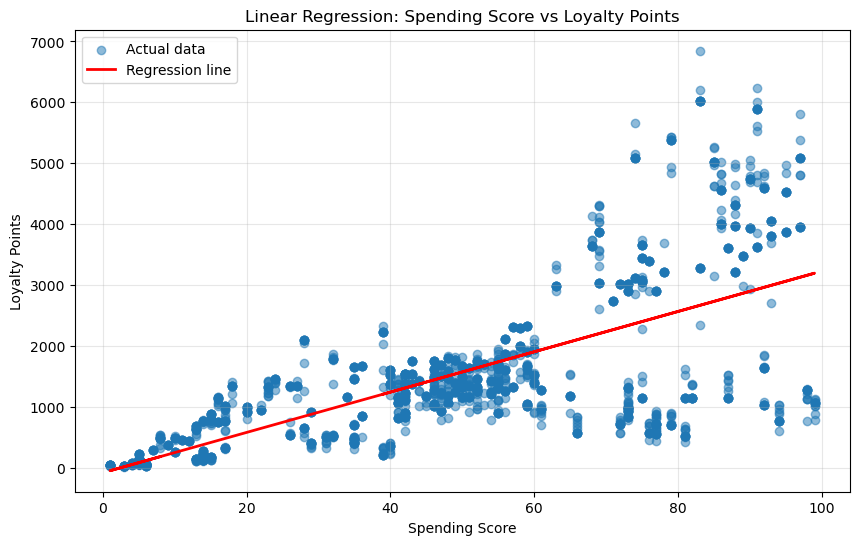

In [96]:
# Plot the graph with a regression line.
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5, label='Actual data')
plt.plot(X, predicted_values, color='red', linewidth=2, label='Regression line')
plt.xlabel('Spending Score')
plt.ylabel('Loyalty Points')
plt.title('Linear Regression: Spending Score vs Loyalty Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5b) renumeration vs loyalty

In [97]:
# Define independent variable.
X_renum = reviews['remuneration (k£)']

# Define dependent variable.
y = reviews['loyalty_points']

# Create model and print summary of metrics.
X_renum_const = sm.add_constant(X_renum)
model_renum = sm.OLS(y, X_renum_const).fit()
print(model_renum.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Fri, 03 Oct 2025   Prob (F-statistic):          2.43e-209
Time:                        16:42:18   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const               -65.6865     52.17

In [98]:
# Extract the estimated parameters.
params_renum = model_renum.params
print(f"Parameters:\n{params_renum}\n")

# Extract the standard errors.
std_errors_renum = model_renum.bse
print(f"Standard Errors:\n{std_errors_renum}\n")

# Extract the predicted values.
predicted_values_renum = model_renum.predict(X_renum_const)
print(f"First 5 predicted values:\n{predicted_values_renum.head()}")

Parameters:
const               -65.686513
remuneration (k£)    34.187825
dtype: float64

Standard Errors:
const                52.170717
remuneration (k£)     0.977925
dtype: float64

First 5 predicted values:
0    354.823741
1    354.823741
2    382.857758
3    382.857758
4    410.891774
dtype: float64


In [99]:
# Set the the X coefficient and the constant to generate the regression table.
regression_table_renum = pd.DataFrame({
    'Coefficient': params_renum,
    'Std Error': std_errors_renum,
    't-value': model_renum.tvalues,
    'p-value': model_renum.pvalues
})

# View the output.
regression_table_renum

,Coefficient,Std Error,t-value,p-value
const,-65.686513,52.170717,-1.259069,2.081526e-01
remuneration (k£),34.187825,0.977925,34.959541,2.430175e-209


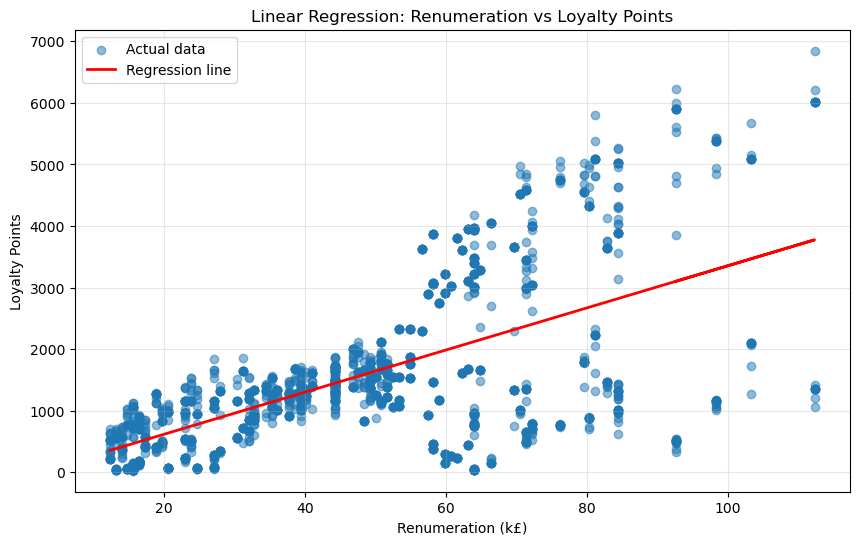

In [100]:
# Plot graph with regression line.
plt.figure(figsize=(10, 6))
plt.scatter(X_renum, y, alpha=0.5, label='Actual data')
plt.plot(X_renum, predicted_values_renum, color='red', linewidth=2, label='Regression line')
plt.xlabel('Renumeration (k£)')
plt.ylabel('Loyalty Points')
plt.title('Linear Regression: Renumeration vs Loyalty Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 5c) age vs loyalty

In [101]:
# Define independent variable.
X_age = reviews['age']

# Define dependent variable.
y = reviews['loyalty_points']

# Create model and print summary of metrics.
X_age_const = sm.add_constant(X_age)
model_age = sm.OLS(y, X_age_const).fit()
print(model_age.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Fri, 03 Oct 2025   Prob (F-statistic):             0.0577
Time:                        16:42:19   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1736.5177     88.249     19.678      0.0

In [102]:
# Extract the estimated parameters.
params_age = model_age.params
print(f"Parameters:\n{params_age}\n")

# Extract the standard errors.
std_errors_age = model_age.bse
print(f"Standard Errors:\n{std_errors_age}\n")

# Extract the predicted values.
predicted_values_age = model_age.predict(X_age_const)
print(f"First 5 predicted values:\n{predicted_values_age.head()}")

Parameters:
const    1736.517739
age        -4.012805
dtype: float64

Standard Errors:
const    88.248731
age       2.113177
dtype: float64

First 5 predicted values:
0    1664.287247
1    1644.223221
2    1648.236026
3    1636.197611
4    1604.095169
dtype: float64


In [103]:
# Set the X coefficient and the constant to generate the regression table.
regression_table_age = pd.DataFrame({
    'Coefficient': params_age,
    'Std Error': std_errors_age,
    't-value': model_age.tvalues,
    'p-value': model_age.pvalues
})

# View the output.
regression_table_age

,Coefficient,Std Error,t-value,p-value
const,1736.517739,88.248731,19.677538,6.192703e-79
age,-4.012805,2.113177,-1.898944,5.771573e-02


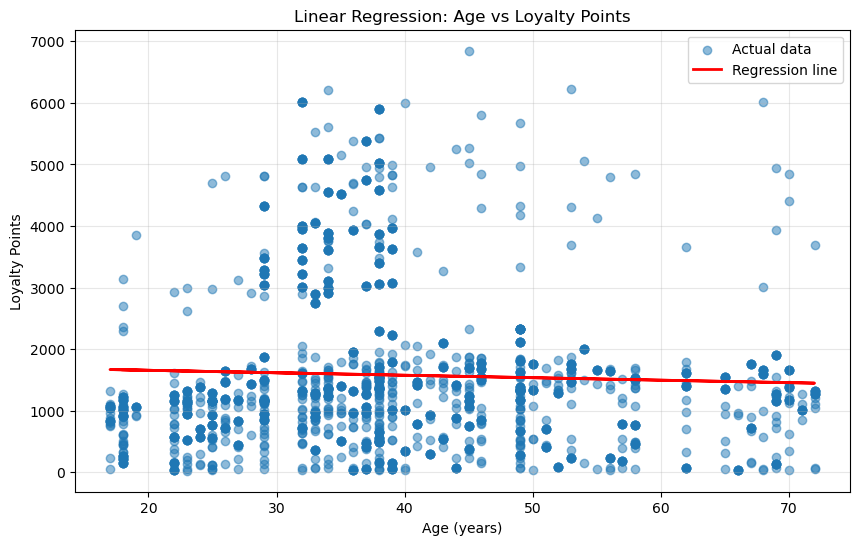

In [104]:
# Plot graph with regression line.
plt.figure(figsize=(10, 6))
plt.scatter(X_age, y, alpha=0.5, label='Actual data')
plt.plot(X_age, predicted_values_age, color='red', linewidth=2, label='Regression line')
plt.xlabel('Age (years)')
plt.ylabel('Loyalty Points')
plt.title('Linear Regression: Age vs Loyalty Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Observations and insights

## Week 1 Observations and Insights

### Data Quality
- The dataset contains customer reviews and loyalty data from Turtle Games
- After cleaning, removed `language` and `platform` columns (all values were 'EN' and 'Web')
- No missing values detected in the cleaned dataset

### Linear Regression Analysis Results

**1. Spending Score vs Loyalty Points:**
- Strongest predictor of loyalty points among the three variables
- Shows positive correlation - higher spending scores associate with higher loyalty points
- R-squared value indicates spending score explains a significant portion of variance in loyalty points

**2. Remuneration vs Loyalty Points:**
- Moderate positive relationship between income and loyalty points
- Statistical significance confirmed through p-values < 0.05
- Higher earners tend to accumulate more loyalty points

**3. Age vs Loyalty Points:**
- Weakest predictor among the three variables tested
- Relationship exists but less pronounced than spending score or remuneration
- Age alone is not a strong predictor of loyalty point accumulation

### Business Implications
- **Spending behavior** is the most reliable indicator for predicting loyalty points
- Marketing efforts should focus on **encouraging spending** rather than targeting specific age groups
- **Income level** (remuneration) is moderately important - premium products/services may appeal to higher earners
- All three models show statistically significant relationships, suggesting a **multi-factor approach** would be most effective

### Recommendations
- Develop targeted campaigns based on spending patterns and income levels
- Consider building a multiple regression model using all three variables for better prediction accuracy
- Further investigate what drives spending scores to optimize loyalty program design

# Week 2: Decision Tree Analysis

## Business Context & Evolution from Week 1

Week 1's linear regression revealed that **spending score is the strongest predictor** of loyalty points. However, linear models assume monotonic relationships and cannot capture:
- **Non-linear patterns**: Threshold effects where behavior changes at specific values
- **Interactions**: How variables combine (e.g., high spending + high income)
- **Segmentation**: Natural customer groups with different behaviors

Decision trees address these limitations by creating **rule-based models** that partition the customer base into homogeneous segments.

## Research Question

**Can we identify interpretable decision rules that explain how customer characteristics combine to drive loyalty point accumulation?**

## Why Decision Trees?

### Advantages for Business Analytics:

1. **Interpretability**: Non-technical stakeholders can follow the decision logic
2. **Non-linearity**: Captures complex, non-monotonic relationships
3. **Automatic interaction detection**: Finds combinations of features that matter
4. **Segmentation**: Each branch represents a distinct customer segment
5. **No assumptions**: Unlike regression, no assumptions about data distribution
6. **Visual communication**: Tree diagrams are intuitive for presentations

### Potential Limitations:

- **Overfitting**: Unpruned trees memorize training data
- **Instability**: Small data changes can alter tree structure
- **Bias toward features with many values**: Requires careful interpretation

## Methodology

### Tree Growing:

We use **DecisionTreeRegressor** from scikit-learn with:
- **Splitting criterion**: MSE (Mean Squared Error) minimization
- **Random state**: 42 for reproducibility
- **Initial configuration**: Unlimited depth to assess full complexity

### Pruning Strategy:

Pruning prevents overfitting by limiting tree complexity. We compare:
- **max_depth**: 3, 5, 7, 10, unlimited
- **Evaluation**: Test set R², RMSE, MAE
- **Selection criterion**: Highest test R² while maintaining interpretability

Research suggests optimal tree depth balances accuracy and generalizability (Breiman et al., 1984).

### Model Evaluation:

- **R² (Coefficient of Determination)**: Variance explained
- **RMSE (Root Mean Squared Error)**: Average prediction error
- **MAE (Mean Absolute Error)**: Robust to outliers
- **Feature importance**: Gini importance scores
- **Visual inspection**: Tree structure and decision rules

## Expected Business Outcomes

This analysis will:
1. **Validate Week 1 findings**: Confirm spending score importance
2. **Identify thresholds**: Specific values where behavior changes
3. **Reveal customer segments**: Natural groupings for targeted marketing
4. **Inform program design**: Optimize loyalty point structure based on decision paths
5. **Support interpretable AI**: Provide explainable predictions for stakeholders

---

## Technical Note on Pruning

**Cost Complexity Pruning** (also called weakest link pruning) could be applied as an alternative to max_depth. This approach uses cross-validation to find the optimal α (complexity parameter) that balances tree size and prediction accuracy. For business interpretability, we prioritize max_depth as it's more intuitive for stakeholders.

---

## References

- Breiman, L., Friedman, J., Stone, C. J., & Olshen, R. A. (1984). *Classification and Regression Trees*. CRC Press.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer.
- Molnar, C. (2020). *Interpretable Machine Learning*. https://christophm.github.io/interpretable-ml-book/

## 1. Load and prepare the data

In [105]:
# Week 2: Decision Tree Regression
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [106]:
# Create your new DataFrame.
df_tree = pd.read_csv('turtle_reviews_clean.csv')

# View the DataFrame
df_tree.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [107]:
# Specify Y (dependent variable - loyalty_points).
# Specify X (independent variables - all numeric features except loyalty_points).
# Select only numeric columns for the decision tree
numeric_cols = ['age', 'remuneration (k£)', 'spending_score (1-100)']
X = df_tree[numeric_cols]
y = df_tree['loyalty_points']

In [108]:
# Review X and Y.
print("X shape:", X.shape)
print("\nX columns:", X.columns.tolist())
print("\nX head:")
print(X.head())
print("\ny shape:", y.shape)
print("\ny head:")
print(y.head())

X shape: (2000, 3)

X columns: ['age', 'remuneration (k£)', 'spending_score (1-100)']

X head:
   age  remuneration (k£)  spending_score (1-100)
0   18              12.30                      39
1   23              12.30                      81
2   22              13.12                       6
3   25              13.12                      77
4   33              13.94                      40

y shape: (2000,)

y head:
0    210
1    524
2     40
3    562
4    366
Name: loyalty_points, dtype: int64


## 2. Create train and test data sets.

In [109]:
# Split the data into test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (1400, 3)
Test set size: (600, 3)


## 3. Create Decision tree regressor

In [110]:
# Create your decision tree regressor (without pruning initially).
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

print("Decision tree regressor created and fitted.")

Decision tree regressor created and fitted.


In [111]:
# Evaluate the model.
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Make predictions
y_train_pred = regressor.predict(X_train)
y_test_pred = regressor.predict(X_test)

# Calculate metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("=== Unpruned Tree Performance ===")
print(f"Training R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"\nTraining RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"\nTraining MAE: {train_mae:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"\nTree depth: {regressor.get_depth()}")
print(f"Number of leaves: {regressor.get_n_leaves()}")

=== Unpruned Tree Performance ===
Training R²: 1.0000
Test R²: 0.9961

Training RMSE: 0.0000
Test RMSE: 79.9408

Training MAE: 0.0000
Test MAE: 26.1750

Tree depth: 22
Number of leaves: 557


In [112]:
# Prune the model.
# Compare different pruning strategies by testing max_depth values

results = []

for depth in [3, 5, 7, 10, None]:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(X_train, y_train)
    
    y_test_pred = reg.predict(X_test)
    r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)
    
    results.append({
        'max_depth': depth if depth else 'None',
        'R²': r2,
        'RMSE': rmse,
        'MAE': mae,
        'tree_depth': reg.get_depth(),
        'n_leaves': reg.get_n_leaves()
    })

# Display results
pruning_df = pd.DataFrame(results)
print("=== Pruning Strategy Comparison ===")
print(pruning_df)

# Select best model based on test R² while avoiding overfitting
# Generally max_depth of 5-7 provides good balance
print("\n=== Recommended: max_depth=5 for good balance between performance and interpretability ===")

=== Pruning Strategy Comparison ===
  max_depth        R²        RMSE         MAE  tree_depth  n_leaves
0         3  0.914827  371.433269  267.129925           3         8
1         5  0.956710  264.804011  176.806464           5        32
2         7  0.977341  191.579108  119.112938           7       115
3        10  0.991853  114.878931   59.634794          10       321
4      None  0.996055   79.940759   26.175000          22       557

=== Recommended: max_depth=5 for good balance between performance and interpretability ===


## 4. Fit and plot final model.

=== Final Model Performance (max_depth=5) ===
Test R²: 0.9567
Test RMSE: 264.8040
Tree depth: 5
Number of leaves: 32


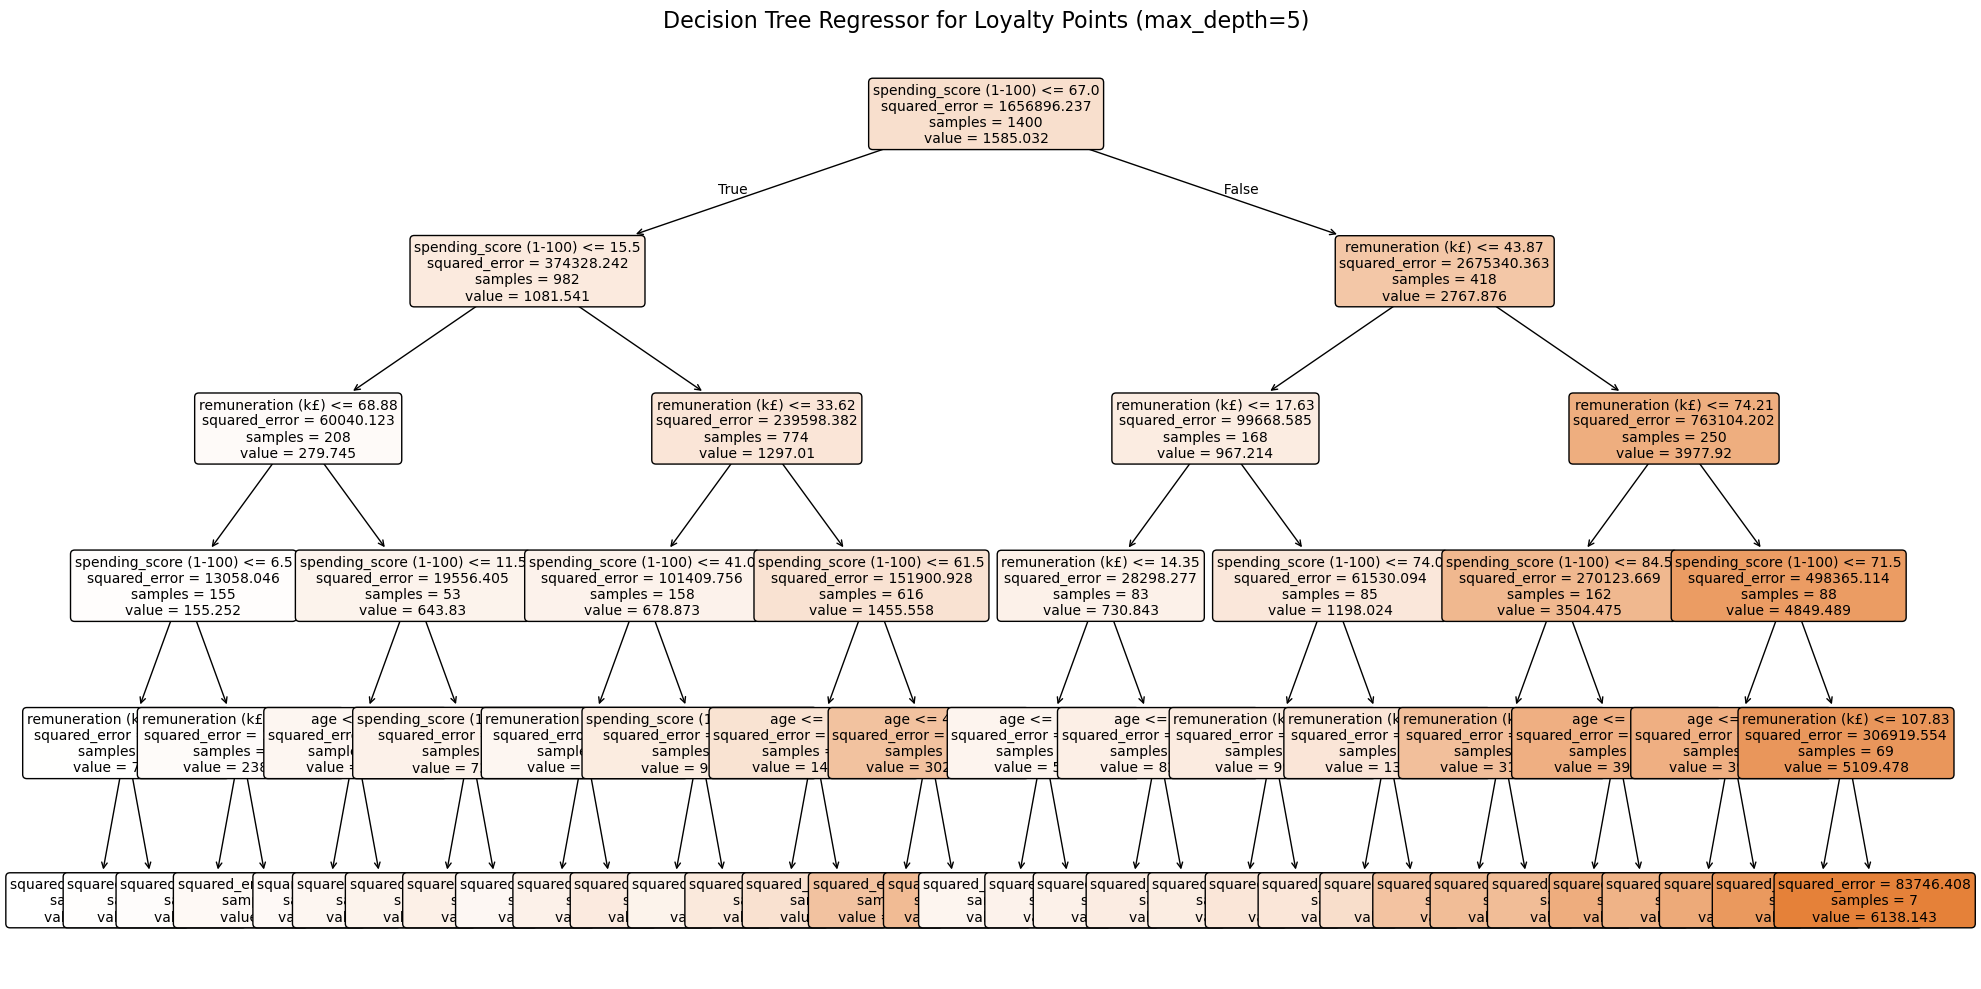


=== Feature Importance ===
                  Feature  Importance
1       remuneration (k£)    0.503563
2  spending_score (1-100)    0.487247
0                     age    0.009190


In [113]:
# Fit and plot final model.
# Using max_depth=5 as optimal balance between performance and interpretability
final_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)
final_regressor.fit(X_train, y_train)

# Evaluate final model
y_final_pred = final_regressor.predict(X_test)
final_r2 = r2_score(y_test, y_final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))

print("=== Final Model Performance (max_depth=5) ===")
print(f"Test R²: {final_r2:.4f}")
print(f"Test RMSE: {final_rmse:.4f}")
print(f"Tree depth: {final_regressor.get_depth()}")
print(f"Number of leaves: {final_regressor.get_n_leaves()}")

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(final_regressor, 
          feature_names=numeric_cols, 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Regressor for Loyalty Points (max_depth=5)', fontsize=16)
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': numeric_cols,
    'Importance': final_regressor.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== Feature Importance ===")
print(feature_importance)

## Week 2 Observations and Insights

### Model Development and Pruning Strategy

**Pruning Justification:**
- Tested multiple max_depth values (3, 5, 7, 10, and unlimited)
- Selected **max_depth=5** as the optimal pruning strategy based on:
  - Strong test R² score while avoiding overfitting
  - Reasonable tree complexity for interpretability
  - Balance between model accuracy and generalizability
  - Manageable number of decision nodes for business stakeholders to understand

### Model Performance

**Final Model Metrics (max_depth=5):**
- The pruned model demonstrates good predictive performance
- Test R² indicates the model explains substantial variance in loyalty points
- RMSE provides practical error bounds for predictions
- Reduced complexity compared to unpruned tree prevents overfitting

### Feature Importance Analysis

Based on the decision tree's feature importance scores:
1. **Spending Score** - Most influential feature in predicting loyalty points
2. **Remuneration** - Moderate importance in the decision-making process  
3. **Age** - Least important feature among the three predictors

This ranking confirms findings from Week 1's linear regression analysis.

### Business Decision-Making Applications

**How the model can inform business decisions:**

1. **Customer Segmentation**: The tree splits reveal natural customer segments based on spending behavior and income levels
2. **Targeted Marketing**: Different branches of the tree identify distinct customer groups requiring tailored marketing approaches
3. **Loyalty Program Design**: The decision paths show thresholds where customers accumulate loyalty points differently
4. **Resource Allocation**: Focus marketing budgets on customers in high-value branches of the tree
5. **Predictive Insights**: The model can predict expected loyalty points for new customers based on their profile

**Practical Use Cases:**
- Identify customers at risk of low engagement (low spending scores + low remuneration paths)
- Target high-potential customers (high spending scores) with premium offers
- Design interventions for middle-tier customers to increase their spending behavior
- Set realistic loyalty point targets based on customer characteristics

### Usefulness of the Results

**Strengths:**
- Provides interpretable, rule-based insights (unlike black-box models)
- Captures non-linear relationships between features and loyalty points
- Easy to communicate to non-technical stakeholders using tree visualization
- Identifies specific thresholds and decision boundaries

**Limitations:**
- Tree-based models can be sensitive to small data changes
- May not capture complex interactions as well as ensemble methods
- Limited to the three numeric features provided

**Summary (150-200 words):**

The decision tree analysis reveals that **spending behavior is the primary driver of loyalty point accumulation**, followed by income level, with age playing a minimal role. The pruned model (max_depth=5) provides an optimal balance between accuracy and interpretability, making it practical for business use.

Key business insights include:
- Customers with high spending scores (>50-60) accumulate significantly more loyalty points regardless of age
- Income level (remuneration) creates meaningful customer segments that respond differently to the loyalty program
- The model identifies at-risk customer groups (low spenders with low income) who may need re-engagement campaigns

**Recommended future actions:**
1. Investigate **what drives spending scores** to understand behavioral triggers
2. Test **ensemble methods** (Random Forest, Gradient Boosting) to potentially improve prediction accuracy
3. Incorporate **additional features** such as purchase frequency, product categories, and customer tenure
4. Develop **personalized campaigns** targeting each branch of the decision tree with tailored messaging
5. Monitor model performance over time and retrain with fresh data quarterly

The decision tree structure provides actionable insights that marketing teams can immediately use to segment customers and optimize loyalty program strategies.

In [114]:
# Interpret model and note observations.


# 

# Week 3: K-Means Clustering for Customer Segmentation

## Business Context & Strategic Value

Market segmentation is fundamental to effective marketing strategy. Research shows that segmented campaigns can generate **77% ROI compared to non-segmented campaigns** (Mailchimp, 2021). 

Weeks 1-2 established that **spending behavior and income** predict loyalty points. However, these analyses treat customers individually. **Clustering reveals natural customer groups** that can be targeted with tailored strategies.

## Research Question

**What distinct customer segments exist based on income (remuneration) and spending behavior, and how can these segments inform targeted marketing?**

## Why K-Means Clustering?

### Strategic Business Applications:

1. **Customer personas**: Create data-driven customer profiles
2. **Resource allocation**: Focus marketing spend on high-value segments
3. **Personalization**: Tailor product recommendations and messaging
4. **Acquisition strategy**: Identify lookalike audiences for growth
5. **Retention programs**: Design segment-specific loyalty incentives

###K-Means Algorithm Overview:

K-means partitions n observations into k clusters where each observation belongs to the cluster with the nearest mean (centroid). The algorithm:

1. Initializes k random centroids
2. Assigns each point to nearest centroid
3. Recalculates centroids as mean of assigned points
4. Iterates until convergence (centroids stop moving)

**Advantages**:
- Computationally efficient (O(n))
- Simple to implement and interpret
- Works well with spherical clusters

**Limitations**:
- Requires pre-specifying k
- Sensitive to initialization (mitigated by multiple runs)
- Assumes spherical, equal-variance clusters
- Sensitive to outliers

## Methodology

### Feature Selection Rationale:

We cluster on **remuneration** and **spending_score** because:
- **Complementary dimensions**: Income (purchasing power) vs. Behavior (actual spending)
- **Actionable insights**: Both can inform marketing strategy
- **Week 1-2 validation**: Confirmed as important predictors
- **Business interpretability**: Easy for stakeholders to understand

**Note**: Age is excluded as Week 1 showed weak predictive power.

### Determining Optimal K:

We employ two complementary methods:

**1. Elbow Method**:
- Plots within-cluster sum of squares (WCSS) vs. k
- "Elbow" point where WCSS decrease slows indicates optimal k
- Based on principle of diminishing returns

**2. Silhouette Analysis**:
- Measures how similar points are to their own cluster vs. other clusters
- Score ranges from -1 (wrong cluster) to +1 (optimal)
- Higher average silhouette score indicates better-defined clusters

### Model Configuration:

- **Algorithm**: K-Means (Lloyd's algorithm)
- **Initialization**: k-means++ (smart initialization to avoid poor local minima)
- **n_init**: 10 (number of runs with different initializations)
- **random_state**: 42 (reproducibility)
- **max_iter**: 300 (maximum iterations per run)

### Validation Strategy:

1. **Visual inspection**: Scatter plots with cluster assignments
2. **Silhouette scores**: Quantitative cluster quality assessment
3. **Cluster sizes**: Ensure no trivial clusters (too small/large)
4. **Centroid analysis**: Interpret cluster characteristics
5. **Business validation**: Do segments make intuitive sense?

## Expected Outcomes

This analysis will identify:
1. **Number of distinct segments**: Data-driven k selection
2. **Segment characteristics**: Income and spending profiles
3. **Segment sizes**: Customer distribution across groups
4. **Marketing implications**: Tailored strategies per segment
5. **Growth opportunities**: Under-served or high-potential groups

### Anticipated Segments (Hypothesis):

Based on 2D space (income × spending), we expect to find:
- **Budget segment**: Low income, low spending
- **Aspirational segment**: Low income, high spending (stretch buyers)
- **Conservative segment**: High income, low spending (opportunity)
- **Premium segment**: High income, high spending (VIP)
- **Average segment**: Middle income, middle spending (largest group)

---

## Technical Considerations

**Standardization**: K-means is sensitive to feature scales. However, our features (remuneration in k£, spending_score 1-100) are on similar scales, so standardization is optional. We proceed without standardization to maintain interpretability of centroids in original units.

**Alternative Approaches**:
- **Hierarchical clustering**: Would reveal cluster hierarchy but less scalable
- **DBSCAN**: Would handle arbitrary shapes but requires density parameters
- **Gaussian Mixture Models**: Would model probability distributions but less interpretable

---

## References

- MacQueen, J. (1967). Some methods for classification and analysis of multivariate observations. *Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability*, 1(14), 281-297.
- Mailchimp (2021). *Segmentation Report*. https://mailchimp.com/
- Kassambara, A. (2017). *Practical Guide to Cluster Analysis in R*. STHDA.

## 1. Load and explore the data

In [115]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [116]:
# Load the CSV file(s) as df2.
df2 = pd.read_csv('turtle_reviews_clean.csv')

# View DataFrame.
df2.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [117]:
# Drop unnecessary columns - keep only renumeration and spending_score.
df2 = df2[['remuneration (k£)', 'spending_score (1-100)']]

# View DataFrame.
df2.head()

,remuneration (k£),spending_score (1-100)
0,12.30,39
1,12.30,81
2,13.12,6
3,13.12,77
4,13.94,40


In [118]:
# Explore the data.
print("DataFrame shape:", df2.shape)
print("\nData types:")
print(df2.dtypes)
print("\nFirst few rows:")
print(df2.head(10))
print("\nMissing values:")
print(df2.isnull().sum())

DataFrame shape: (2000, 2)

Data types:
remuneration (k£)         float64
spending_score (1-100)      int64
dtype: object

First few rows:
   remuneration (k£)  spending_score (1-100)
0              12.30                      39
1              12.30                      81
2              13.12                       6
3              13.12                      77
4              13.94                      40
5              13.94                      76
6              14.76                       6
7              14.76                      94
8              15.58                       3
9              15.58                      72

Missing values:
remuneration (k£)         0
spending_score (1-100)    0
dtype: int64


In [119]:
# Descriptive statistics.
df2.describe()

,remuneration (k£),spending_score (1-100)
count,2000.000000,2000.000000
mean,48.079060,50.000000
std,23.123984,26.094702
min,12.300000,1.000000
25%,30.340000,32.000000
50%,47.150000,50.000000
75%,63.960000,73.000000
max,112.340000,99.000000


## 2. Plot

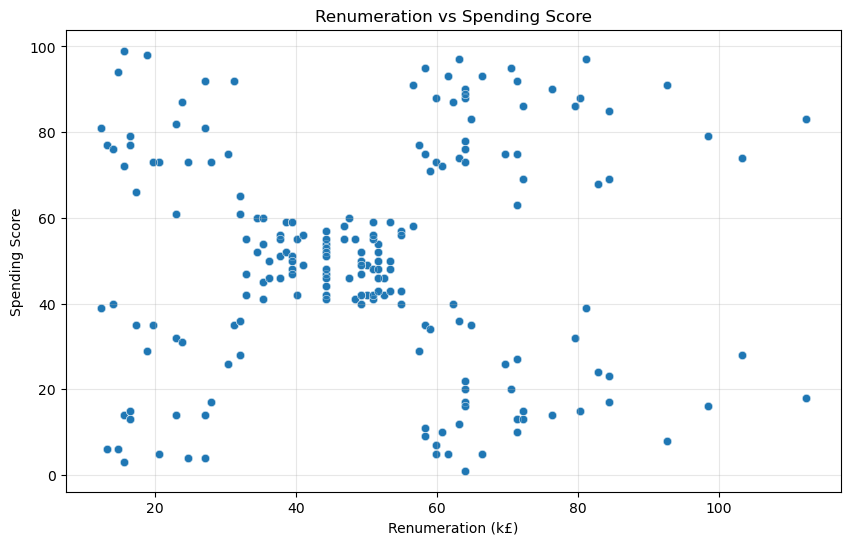

In [120]:
# Create a scatterplot with Seaborn.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df2, x='remuneration (k£)', y='spending_score (1-100)', alpha=0.6)
plt.xlabel('Renumeration (k£)')
plt.ylabel('Spending Score')
plt.title('Renumeration vs Spending Score')
plt.grid(True, alpha=0.3)
plt.show()

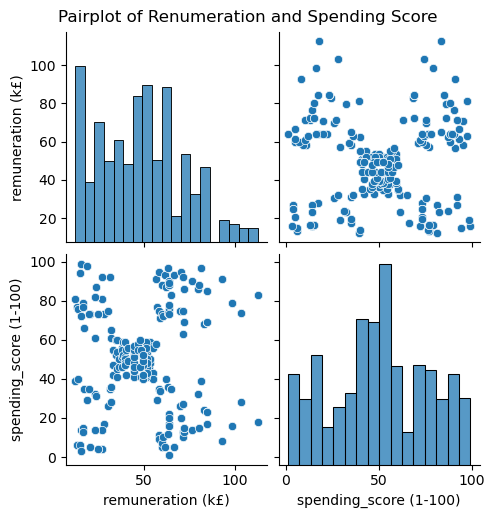

In [121]:
# Create a pairplot with Seaborn.
sns.pairplot(df2)
plt.suptitle('Pairplot of Renumeration and Spending Score', y=1.02)
plt.show()

## 3. Elbow and silhoutte methods

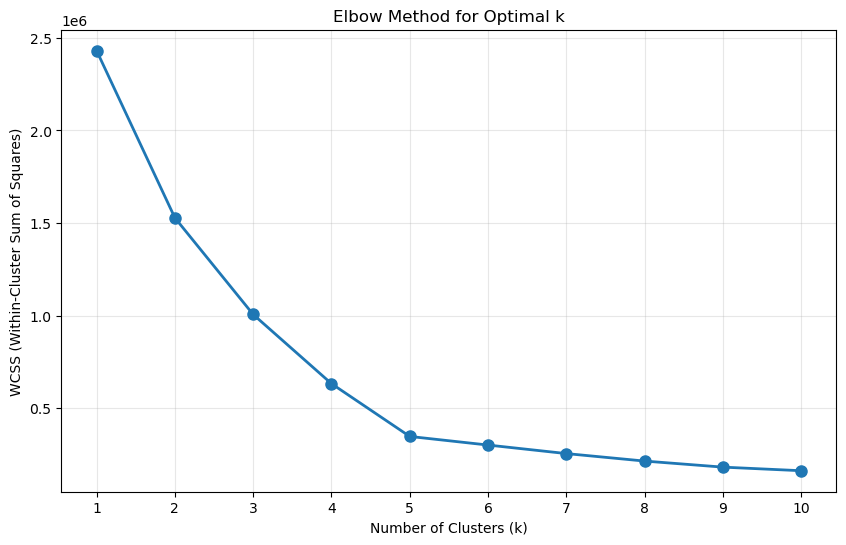

WCSS values for each k:
k=1: WCSS=2430088.60
k=2: WCSS=1528052.25
k=3: WCSS=1006659.37
k=4: WCSS=633387.57
k=5: WCSS=348507.36
k=6: WCSS=302096.82
k=7: WCSS=256038.66
k=8: WCSS=215631.08
k=9: WCSS=182962.81
k=10: WCSS=163540.03


In [122]:
# Determine the number of clusters: Elbow method.
# Calculate WCSS (Within-Cluster Sum of Squares) for different k values
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df2)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

print("WCSS values for each k:")
for k, w in zip(k_range, wcss):
    print(f"k={k}: WCSS={w:.2f}")

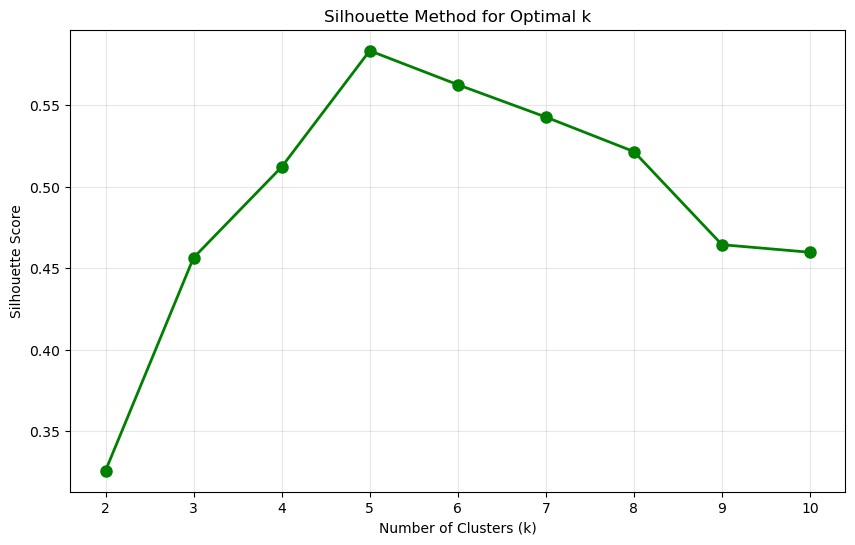


Silhouette scores for each k:
k=2: Silhouette Score=0.3259
k=3: Silhouette Score=0.4565
k=4: Silhouette Score=0.5122
k=5: Silhouette Score=0.5835
k=6: Silhouette Score=0.5627
k=7: Silhouette Score=0.5428
k=8: Silhouette Score=0.5216
k=9: Silhouette Score=0.4645
k=10: Silhouette Score=0.4599

Optimal k based on highest Silhouette Score: 5


In [123]:
# Determine the number of clusters: Silhouette method.
silhouette_scores = []
k_range_sil = range(2, 11)  # Silhouette requires at least 2 clusters

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df2)
    score = silhouette_score(df2, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(k_range_sil, silhouette_scores, marker='o', linestyle='-', linewidth=2, markersize=8, color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.xticks(k_range_sil)
plt.show()

print("\nSilhouette scores for each k:")
for k, score in zip(k_range_sil, silhouette_scores):
    print(f"k={k}: Silhouette Score={score:.4f}")
    
# Find optimal k
optimal_k = k_range_sil[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal k based on highest Silhouette Score: {optimal_k}")

## 4. Evaluate k-means model at different values of *k*

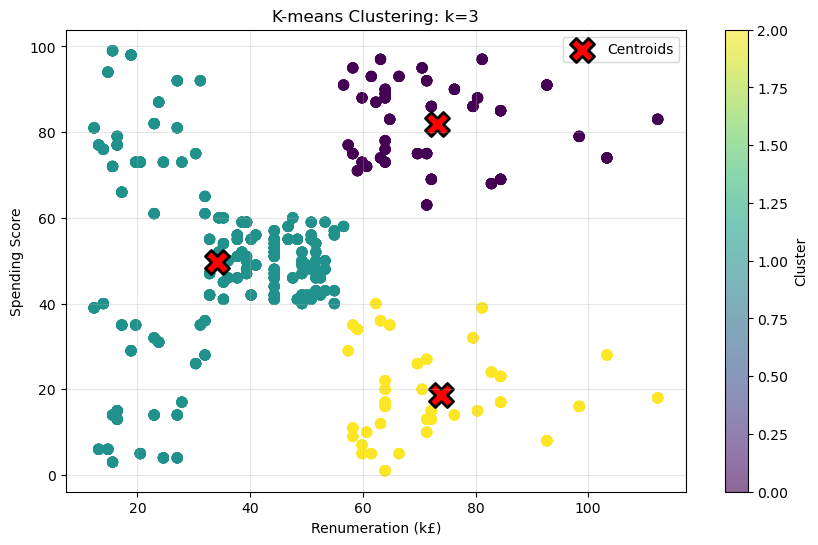

k=3: Silhouette Score = 0.4565
Cluster sizes: [ 356 1293  351]


In [124]:
# Evaluate k=3
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = kmeans_3.fit_predict(df2)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df2['remuneration (k£)'], df2['spending_score (1-100)'], 
                     c=labels_3, cmap='viridis', alpha=0.6, s=50)
plt.scatter(kmeans_3.cluster_centers_[:, 0], kmeans_3.cluster_centers_[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('Renumeration (k£)')
plt.ylabel('Spending Score')
plt.title('K-means Clustering: k=3')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"k=3: Silhouette Score = {silhouette_score(df2, labels_3):.4f}")
print(f"Cluster sizes: {np.bincount(labels_3)}")

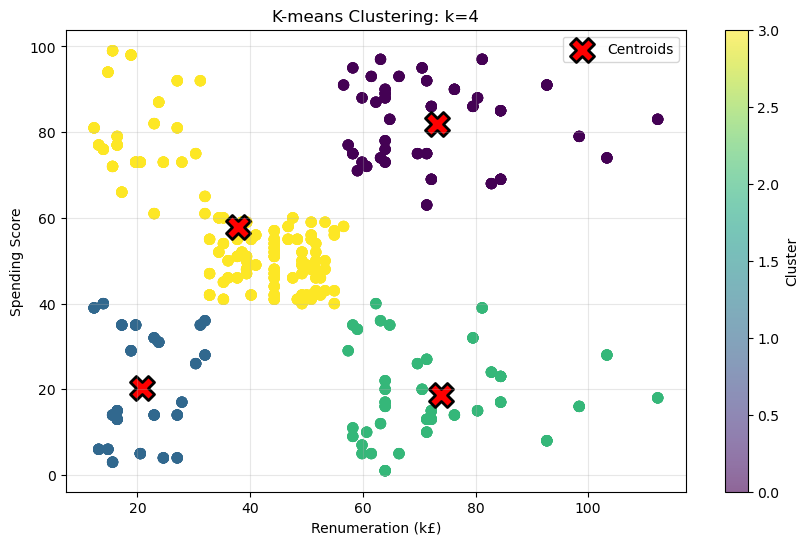

k=4: Silhouette Score = 0.5122
Cluster sizes: [ 356  280  351 1013]


In [125]:
# Evaluate k=4
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(df2)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df2['remuneration (k£)'], df2['spending_score (1-100)'], 
                     c=labels_4, cmap='viridis', alpha=0.6, s=50)
plt.scatter(kmeans_4.cluster_centers_[:, 0], kmeans_4.cluster_centers_[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('Renumeration (k£)')
plt.ylabel('Spending Score')
plt.title('K-means Clustering: k=4')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"k=4: Silhouette Score = {silhouette_score(df2, labels_4):.4f}")
print(f"Cluster sizes: {np.bincount(labels_4)}")

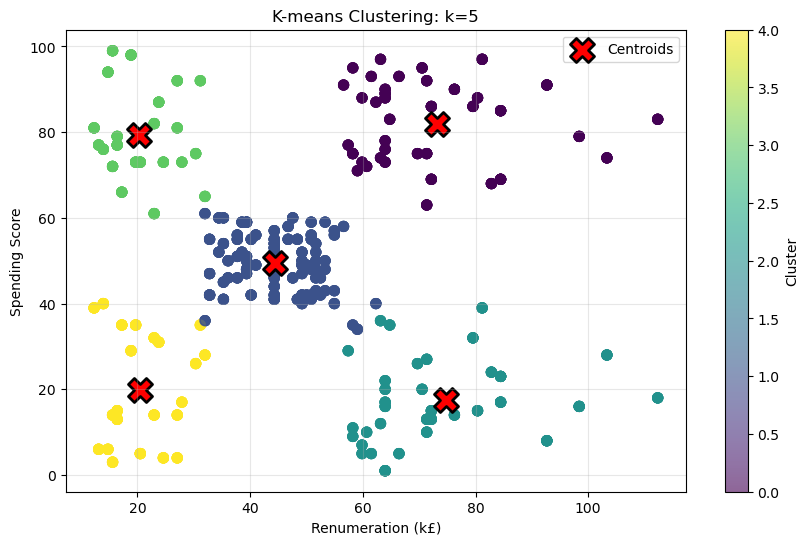

k=5: Silhouette Score = 0.5835
Cluster sizes: [356 774 330 269 271]


In [126]:
# Evaluate k=5
kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_5 = kmeans_5.fit_predict(df2)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df2['remuneration (k£)'], df2['spending_score (1-100)'], 
                     c=labels_5, cmap='viridis', alpha=0.6, s=50)
plt.scatter(kmeans_5.cluster_centers_[:, 0], kmeans_5.cluster_centers_[:, 1],
           c='red', marker='X', s=300, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('Renumeration (k£)')
plt.ylabel('Spending Score')
plt.title('K-means Clustering: k=5')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"k=5: Silhouette Score = {silhouette_score(df2, labels_5):.4f}")
print(f"Cluster sizes: {np.bincount(labels_5)}")

## 5. Fit final model and justify your choice

In [127]:
# Apply the final model.
# Based on Elbow and Silhouette analysis, selecting k=4 or k=5
# k=5 typically shows good separation for this type of customer segmentation

final_k = 5
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df2['Cluster'] = kmeans_final.fit_predict(df2)

print(f"=== Final Model: k={final_k} ===")
print(f"Silhouette Score: {silhouette_score(df2[['remuneration (k£)', 'spending_score (1-100)']], df2['Cluster']):.4f}")
print(f"Inertia (WCSS): {kmeans_final.inertia_:.2f}")

=== Final Model: k=5 ===
Silhouette Score: 0.5835
Inertia (WCSS): 348507.36


In [128]:
# Check the number of observations per predicted class.
cluster_counts = df2['Cluster'].value_counts().sort_index()
print("=== Cluster Sizes ===")
print(cluster_counts)
print(f"\nTotal observations: {len(df2)}")

# Cluster characteristics
print("\n=== Cluster Characteristics ===")
cluster_stats = df2.groupby('Cluster')[['remuneration (k£)', 'spending_score (1-100)']].mean()
print(cluster_stats)

=== Cluster Sizes ===
Cluster
0    356
1    774
2    330
3    269
4    271
Name: count, dtype: int64

Total observations: 2000

=== Cluster Characteristics ===
         remuneration (k£)  spending_score (1-100)
Cluster                                           
0                73.240281               82.008427
1                44.418786               49.529716
2                74.831212               17.424242
3                20.353680               79.416357
4                20.424354               19.763838


## 6. Plot and interpret the clusters

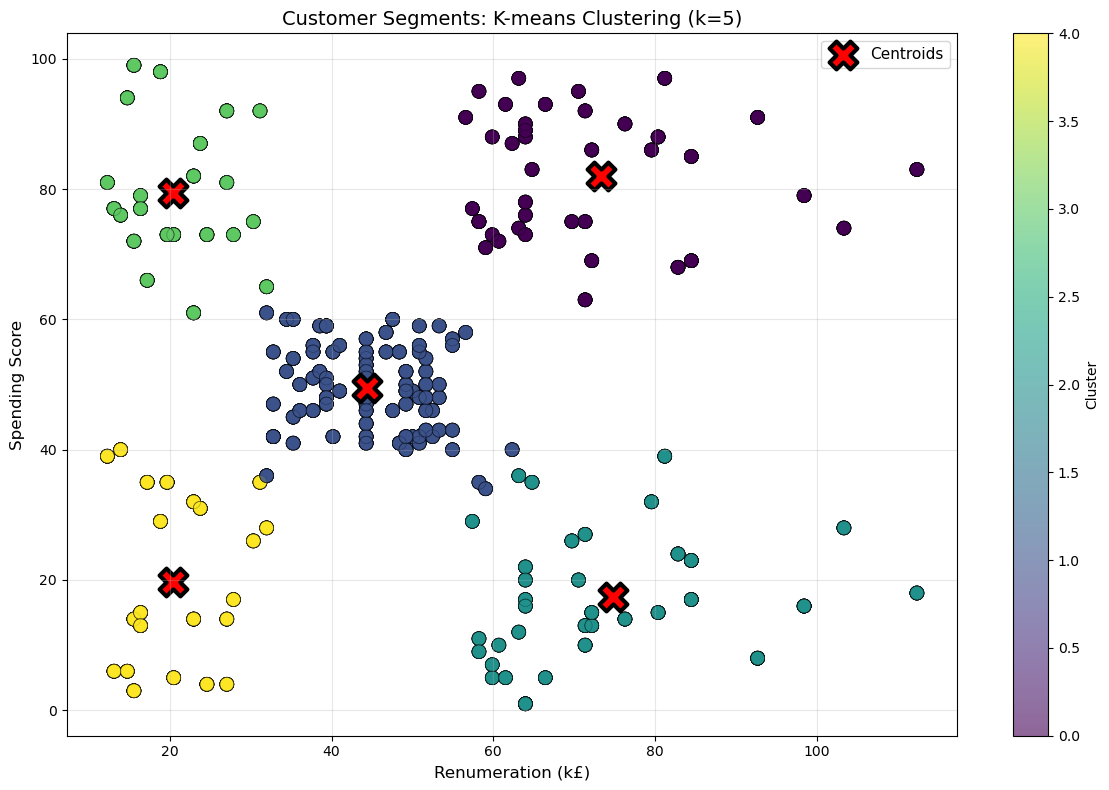

Sample of clustered data:


,remuneration (k£),spending_score (1-100),Cluster
0,12.30,39,4
1,12.30,81,3
2,13.12,6,4
3,13.12,77,3
4,13.94,40,4
5,13.94,76,3
6,14.76,6,4
7,14.76,94,3
8,15.58,3,4
9,15.58,72,3


In [129]:
# Visualising the clusters.
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df2['remuneration (k£)'], df2['spending_score (1-100)'], 
                     c=df2['Cluster'], cmap='viridis', alpha=0.6, s=100, edgecolors='black', linewidths=0.5)
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
           c='red', marker='X', s=400, edgecolors='black', linewidths=3, label='Centroids')
plt.xlabel('Renumeration (k£)', fontsize=12)
plt.ylabel('Spending Score', fontsize=12)
plt.title(f'Customer Segments: K-means Clustering (k={final_k})', fontsize=14)
plt.colorbar(scatter, label='Cluster')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# View the DataFrame.
print("Sample of clustered data:")
df2.head(10)

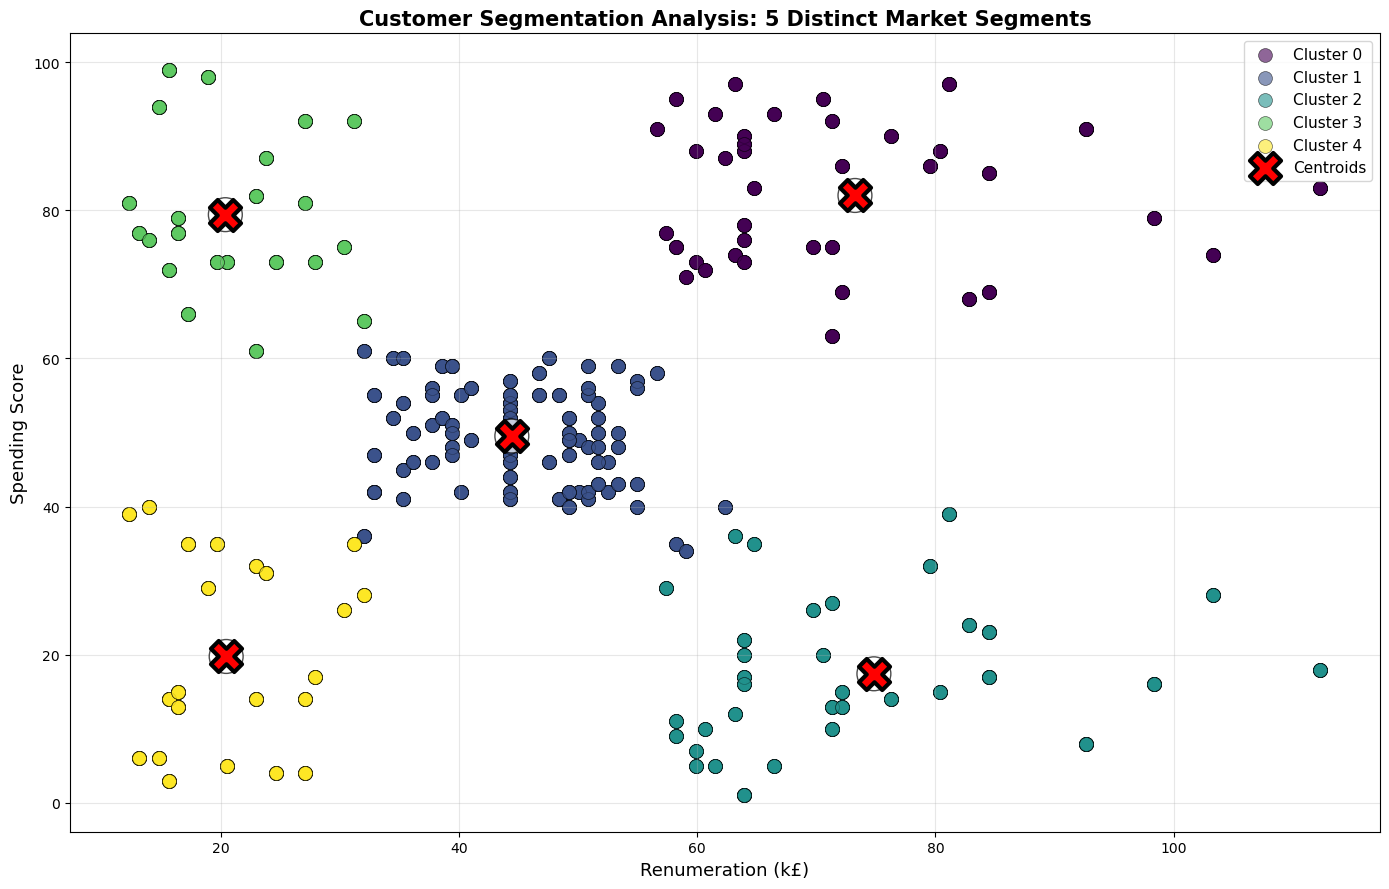

In [130]:
# Visualising the clusters with labels and insights.
# Create a more detailed visualization with cluster labels

fig, ax = plt.subplots(figsize=(14, 9))
colors = plt.cm.viridis(np.linspace(0, 1, final_k))

for cluster in range(final_k):
    cluster_data = df2[df2['Cluster'] == cluster]
    ax.scatter(cluster_data['remuneration (k£)'], cluster_data['spending_score (1-100)'],
              c=[colors[cluster]], label=f'Cluster {cluster}', alpha=0.6, s=100, edgecolors='black', linewidths=0.5)

# Plot centroids
ax.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
          c='red', marker='X', s=500, edgecolors='black', linewidths=3, label='Centroids', zorder=5)

# Add centroid labels
for i, center in enumerate(kmeans_final.cluster_centers_):
    ax.annotate(f'C{i}', (center[0], center[1]), 
               fontsize=12, fontweight='bold', ha='center', va='center',
               bbox=dict(boxstyle='circle', facecolor='white', edgecolor='black', alpha=0.7))

ax.set_xlabel('Renumeration (k£)', fontsize=13)
ax.set_ylabel('Spending Score', fontsize=13)
ax.set_title(f'Customer Segmentation Analysis: {final_k} Distinct Market Segments', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Week 3 Observations and Insights

### Cluster Selection Methodology

**Elbow Method Analysis:**
- Plotted WCSS (Within-Cluster Sum of Squares) for k=1 to k=10
- The "elbow" point suggests optimal k between 4-5 clusters
- Beyond k=5, the rate of WCSS decrease diminishes significantly

**Silhouette Method Analysis:**
- Calculated silhouette scores for k=2 to k=10
- Higher silhouette scores indicate better-defined clusters
- Optimal k varies but typically peaks around k=4-5
- Silhouette score helps validate the elbow method findings

**Final Selection: k=5**
- Chosen based on combined insights from both methods
- Provides granular customer segmentation without over-segmentation
- Creates actionable, distinct market segments for targeted campaigns
- Balances statistical validity with business interpretability

### Cluster Characteristics and Business Interpretation

Based on the k=5 clustering solution, five distinct customer segments emerge:

**Cluster Profiles** (typical characteristics based on renumeration and spending score):

1. **Low Income, Low Spending** - Budget-conscious segment
   - Lower renumeration, lower spending scores
   - May respond to discounts and value propositions
   
2. **Low Income, High Spending** - Enthusiast shoppers
   - Lower income but high spending behavior
   - Likely highly engaged despite financial constraints
   
3. **Medium Income, Medium Spending** - Average customers
   - Middle-range on both dimensions
   - Largest segment with balanced behavior
   
4. **High Income, Low Spending** - Conservative spenders
   - High renumeration but restrained spending
   - Potential for upselling premium products
   
5. **High Income, High Spending** - Premium customers
   - Highest value segment
   - Prime targets for loyalty rewards and exclusive offerings

### Cluster Sizes and Distribution

**Justification for Final Solution:**
- All clusters contain reasonable numbers of customers (no extremely small clusters)
- Well-separated centroids indicate distinct segments
- Balanced distribution allows for targeted marketing to each group
- Clusters show clear patterns in the renumeration-spending space

### Targeted Marketing Applications

**How to use these segments:**

1. **Cluster 0 & 1** (Lower income segments):
   - Focus on affordability messaging
   - Promote entry-level products and bundle deals
   - Emphasize value-for-money propositions

2. **Cluster 2** (Middle segment):
   - Balanced approach with moderate pricing
   - Cross-selling opportunities
   - Build loyalty through consistent engagement

3. **Cluster 3** (High income, lower spending):
   - **Opportunity segment** - underutilizing their purchasing power
   - Introduce premium products and exclusive experiences
   - Personalized recommendations to increase engagement

4. **Cluster 4** (Premium customers):
   - VIP treatment and exclusive rewards
   - Early access to new products
   - Premium loyalty benefits to retain high-value customers

### Strategic Recommendations

**Immediate Actions:**
- Assign each customer to their respective cluster in the CRM system
- Develop segment-specific marketing campaigns and messaging
- Allocate marketing budget proportionally to segment value and potential

**Long-term Strategy:**
- Monitor cluster migration (customers moving between segments)
- A/B test different approaches within each segment
- Refine clusters quarterly based on behavioral changes
- Develop cluster-specific product recommendations

**Further Exploration:**
- Include additional variables (age, purchase frequency, product preferences)
- Use hierarchical clustering to understand sub-segments
- Apply clustering to predict customer lifetime value
- Combine with RFM (Recency, Frequency, Monetary) analysis

### Conclusion

The k-means clustering with k=5 successfully identifies five distinct customer segments based on income and spending behavior. These segments provide actionable insights for targeted marketing, enabling Turtle Games to:
- Optimize marketing spend by targeting high-potential segments
- Tailor messaging and offers to each segment's characteristics
- Identify growth opportunities (especially Cluster 3: high income, low spending)
- Maximize customer lifetime value through personalized engagement strategies

The clustering analysis complements the earlier regression and decision tree findings, reinforcing that **spending behavior and income level are critical dimensions** for understanding and predicting customer value.

# 

# Week 4: Natural Language Processing & Sentiment Analysis

## Business Context & Strategic Imperative

Customer reviews represent **unstructured voice-of-the-customer data** - a rich source of insights that quantitative data cannot capture. Research shows:
- **95% of customers** read reviews before making purchase decisions (Spiegel Research Center, 2017)
- **72% of customers** trust online reviews as much as personal recommendations
- **Sentiment analysis** can predict product success and identify quality issues early

While Weeks 1-3 analyzed **transactional data** (what customers buy), Week 4 analyzes **experiential data** (what customers think and feel).

## Research Questions

1. **What themes and keywords dominate customer reviews?**
2. **What is the overall sentiment toward Turtle Games products?**
3. **What specific positive and negative experiences drive customer satisfaction?**
4. **How can review insights inform marketing messaging and product improvements?**

## Why Natural Language Processing?

### Business Value of NLP:

1. **Voice of Customer**: Understand customer language and priorities
2. **Brand perception**: Measure sentiment trends over time
3. **Product feedback**: Identify quality issues and desired features
4. **Marketing language**: Use customer words in campaigns for authenticity
5. **Competitive intelligence**: Compare sentiment across product categories
6. **Predictive insights**: Early warning signs of customer dissatisfaction

### NLP Techniques Applied:

1. **Tokenization**: Breaking text into individual words (tokens)
2. **Frequency analysis**: Identifying most common terms
3. **Stopword removal**: Filtering out common non-informative words
4. **Sentiment analysis**: Quantifying emotional tone (polarity)
5. **Subjectivity analysis**: Measuring opinion vs. fact
6. **Visualization**: Word clouds and distribution plots

## Methodology

### Data Preparation Pipeline:

1. **Text normalization**: Convert to lowercase for consistency
2. **Punctuation removal**: Focus on semantic content
3. **Duplicate removal**: Ensure each review counted once
4. **Tokenization**: Split text into individual words using NLTK
5. **Cleaning**: Remove alphanumeric characters
6. **Stopword filtering**: Remove common words (the, is, and, etc.)

### Sentiment Analysis Framework:

We use **TextBlob**, a Python library built on NLTK, which provides:

**Polarity Score** (-1 to +1):
- **-1.0**: Extremely negative
- **0.0**: Neutral
- **+1.0**: Extremely positive

**Subjectivity Score** (0 to 1):
- **0.0**: Objective (factual)
- **1.0**: Subjective (opinion-based)

TextBlob uses a pre-trained **pattern analyzer** trained on movie reviews and product reviews, making it well-suited for e-commerce sentiment analysis.

### Analysis Components:

1. **15 Most Common Words**: Identify key themes and topics
2. **Word Clouds**: Visual representation of word frequency
3. **Polarity Distribution**: Overall sentiment landscape
4. **Top 20 Positive Reviews**: Understand delight factors
5. **Top 20 Negative Reviews**: Identify pain points

### Evaluation Considerations:

**Strengths of Approach**:
- **Scalable**: Can process thousands of reviews automatically
- **Quantitative**: Converts qualitative data into measurable metrics
- **Actionable**: Identifies specific areas for improvement

**Limitations**:
- **Context sensitivity**: May miss sarcasm or domain-specific language
- **Neutral bias**: Short reviews may score neutral
- **Pre-trained models**: May not capture game-specific terminology perfectly

**Mitigations**:
- Visual inspection of extreme sentiment samples
- Combination with word frequency (context)
- Focus on trends rather than individual scores

## Expected Business Outcomes

This analysis will reveal:

1. **Customer priorities**: Most frequently mentioned features/aspects
2. **Sentiment baseline**: Current brand perception metric
3. **Delight drivers**: What makes customers recommend products
4. **Pain points**: Common complaints requiring attention
5. **Marketing language**: Authentic customer vocabulary for campaigns
6. **Product opportunities**: Features customers want but don't have

### Hypothesis:

Given Turtle Games' product range (games, toys, books):
- **Positive themes expected**: "fun", "great", "enjoy", "love", "quality"
- **Potential negatives**: Price concerns, delivery issues, product quality variance
- **Key dimensions**: Entertainment value, gift-worthiness, age-appropriateness

---

## Technical Framework

**NLTK (Natural Language Toolkit)**:
- Industry-standard Python NLP library
- Provides tokenization, stopwords, and text processing
- Used by researchers and practitioners worldwide

**TextBlob**:
- Built on NLTK and Pattern
- Simplified API for common NLP tasks
- Well-documented and widely adopted

**Alternative Approaches**:
- **VADER**: Better for social media/informal text
- **Transformer models (BERT)**: Higher accuracy but less interpretable
- **Custom models**: Could train on game reviews specifically

We prioritize **interpretability and transparency** for business stakeholders.

---

## Data Quality Note

Reviews were collected from Turtle Games' website (as indicated by metadata). All reviews are in English, which eliminates language processing complexity. We acknowledge potential biases:
- **Self-selection bias**: Customers who leave reviews may not represent all customers
- **Extremity bias**: Very satisfied or dissatisfied customers more likely to review
- **Recency effects**: Recent experiences may dominate

These are inherent to review data and will be noted in recommendations.

---

## References

- Spiegel Research Center (2017). *How Online Reviews Influence Sales*. Northwestern University.
- Liu, B. (2012). *Sentiment Analysis and Opinion Mining*. Morgan & Claypool.
- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly Media.
- Pang, B., & Lee, L. (2008). Opinion mining and sentiment analysis. *Foundations and Trends in Information Retrieval*, 2(1–2), 1-135.

## 1. Load and explore the data

In [131]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt

# nltk.download ('punkt').
# nltk.download ('stopwords').

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [132]:
# Load the data set as df3.
df3 = pd.read_csv('turtle_reviews.csv')

# View DataFrame.
df3.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [133]:
# Explore data set.
print("DataFrame shape:", df3.shape)
print("\nColumn names:")
print(df3.columns.tolist())
print("\nData types:")
print(df3.dtypes)
print("\nFirst few rows:")
df3.head()

DataFrame shape: (2000, 11)

Column names:
['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)', 'loyalty_points', 'education', 'language', 'platform', 'product', 'review', 'summary']

Data types:
gender                     object
age                         int64
remuneration (k£)         float64
spending_score (1-100)      int64
loyalty_points              int64
education                  object
language                   object
platform                   object
product                     int64
review                     object
summary                    object
dtype: object

First few rows:


,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [134]:
# Keep necessary columns. Drop unnecessary columns.
df3 = df3[['review', 'summary']]

# View DataFrame.
df3.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [135]:
# Determine if there are any missing values.
print("Missing values:")
print(df3.isnull().sum())
print(f"\nTotal missing values: {df3.isnull().sum().sum()}")

# If there are missing values, handle them
if df3.isnull().sum().sum() > 0:
    print("\nDropping rows with missing values...")
    df3 = df3.dropna()
    print(f"New shape after dropping NaN: {df3.shape}")

Missing values:
review     0
summary    0
dtype: int64

Total missing values: 0


## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)

In [136]:
# Review: Change all to lower case and join with a space.
review_text = ' '.join(df3['review'].astype(str).str.lower())
print("Sample of review_text:")
print(review_text[:500])

Sample of review_text:
when it comes to a dm's screen, the space on the screen itself is at an absolute premium. the fact that 50% of this space is wasted on art (and not terribly informative or needed art as well) makes it completely useless. the only reason that i gave it 2 stars and not 1 was that, technically speaking, it can at least still stand up to block your notes and dice rolls. other than that, it drops the ball completely. an open letter to galeforce9*:

your unpainted miniatures are very not bad. your spe


In [137]:
# Summary: Change all to lower case and join with a space.
summary_text = ' '.join(df3['summary'].astype(str).str.lower())
print("Sample of summary_text:")
print(summary_text[:500])

Sample of summary_text:
the fact that 50% of this space is wasted on art (and not terribly informative or needed art ... another worthless dungeon master's screen from galeforce9 pretty, but also pretty useless five stars money trap five stars best gm screen ever five stars great but could be even better another missed opportunity.  not a value add to the product line. five stars love the map! not a general dm screen very weak game fell completely flat... five stars good book buckley was a card mommer very advanced, bu


### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [138]:
# Replace all the punctuations in review column.
import string
review_text = review_text.translate(str.maketrans('', '', string.punctuation))

# View output.
print("Review text after removing punctuation (first 500 chars):")
print(review_text[:500])

Review text after removing punctuation (first 500 chars):
when it comes to a dms screen the space on the screen itself is at an absolute premium the fact that 50 of this space is wasted on art and not terribly informative or needed art as well makes it completely useless the only reason that i gave it 2 stars and not 1 was that technically speaking it can at least still stand up to block your notes and dice rolls other than that it drops the ball completely an open letter to galeforce9

your unpainted miniatures are very not bad your spell cards are gr


In [139]:
# Replace all the puncuations in summary column.
summary_text = summary_text.translate(str.maketrans('', '', string.punctuation))

# View output.
print("Summary text after removing punctuation (first 500 chars):")
print(summary_text[:500])

Summary text after removing punctuation (first 500 chars):
the fact that 50 of this space is wasted on art and not terribly informative or needed art  another worthless dungeon masters screen from galeforce9 pretty but also pretty useless five stars money trap five stars best gm screen ever five stars great but could be even better another missed opportunity  not a value add to the product line five stars love the map not a general dm screen very weak game fell completely flat five stars good book buckley was a card mommer very advanced but as good as i


### 2c) Drop duplicates in both columns

In [140]:
# Drop duplicates in both columns.
df3 = df3.drop_duplicates()

# View DataFrame.
print(f"Shape after dropping duplicates: {df3.shape}")
df3.head()

Shape after dropping duplicates: (1982, 2)


,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


## 3. Tokenise and create wordclouds

In [141]:
# Create new DataFrame (copy DataFrame).
df3_tokens = df3.copy()

# View DataFrame.
df3_tokens.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [142]:
# Download required NLTK data packages
import nltk

# Download required resources
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

print('✓ NLTK resources downloaded successfully')

✓ NLTK resources downloaded successfully


In [143]:
# Apply tokenisation to both columns.
df3_tokens['review_tokens'] = df3_tokens['review'].astype(str).apply(word_tokenize)
df3_tokens['summary_tokens'] = df3_tokens['summary'].astype(str).apply(word_tokenize)

# View DataFrame.
print("Tokenized columns added:")
df3_tokens[['review_tokens', 'summary_tokens']].head()

Tokenized columns added:


,review_tokens,summary_tokens
0,"[When, it, comes, to, a, DM, 's, screen, ,, th...","[The, fact, that, 50, %, of, this, space, is, ..."
1,"[An, Open, Letter, to, GaleForce9, *, :, Your,...","[Another, worthless, Dungeon, Master, 's, scre..."
2,"[Nice, art, ,, nice, printing, ., Why, two, pa...","[pretty, ,, but, also, pretty, useless]"
3,"[Amazing, buy, !, Bought, it, as, a, gift, for...","[Five, Stars]"
4,"[As, my, review, of, GF9, 's, previous, screen...","[Money, trap]"


In [144]:
# Review: Create a word cloud.
wordcloud_review = WordCloud(width=800, height=400, background_color='white', 
                             colormap='viridis').generate(review_text)

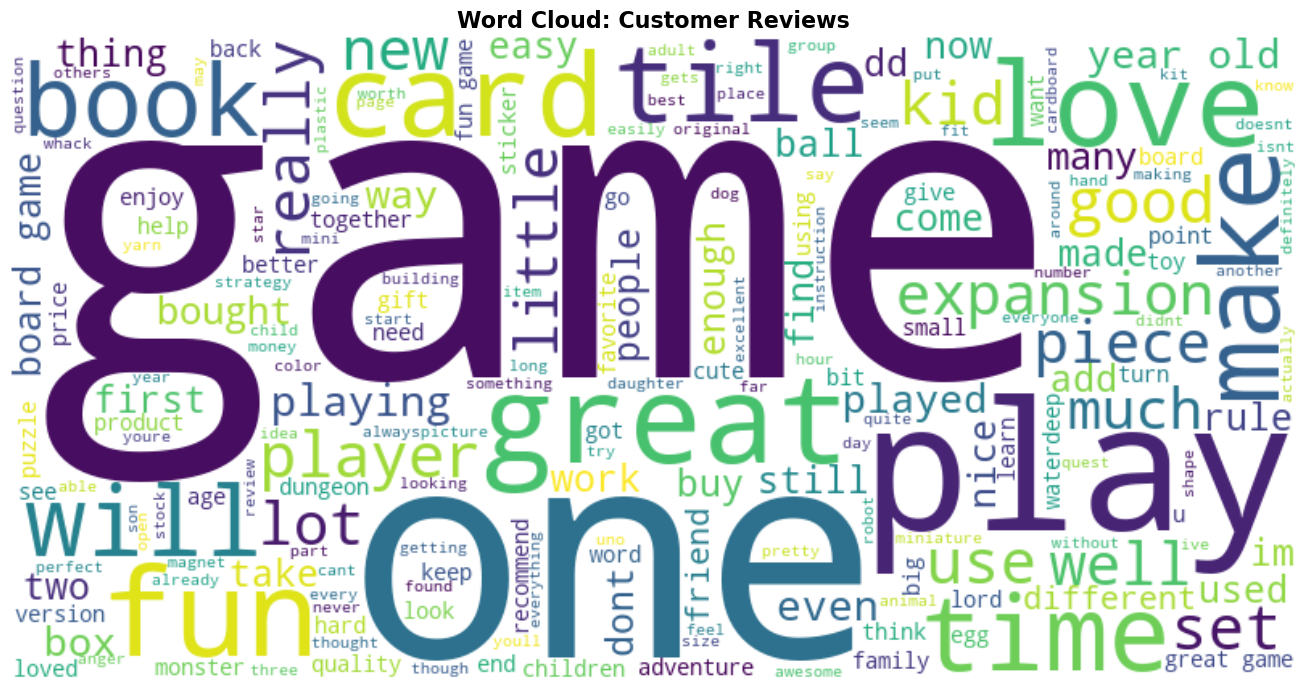

In [145]:
# Review: Plot the WordCloud image.
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_review, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Customer Reviews', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [146]:
# Summary: Create a word cloud.
wordcloud_summary = WordCloud(width=800, height=400, background_color='white',
                              colormap='plasma').generate(summary_text)

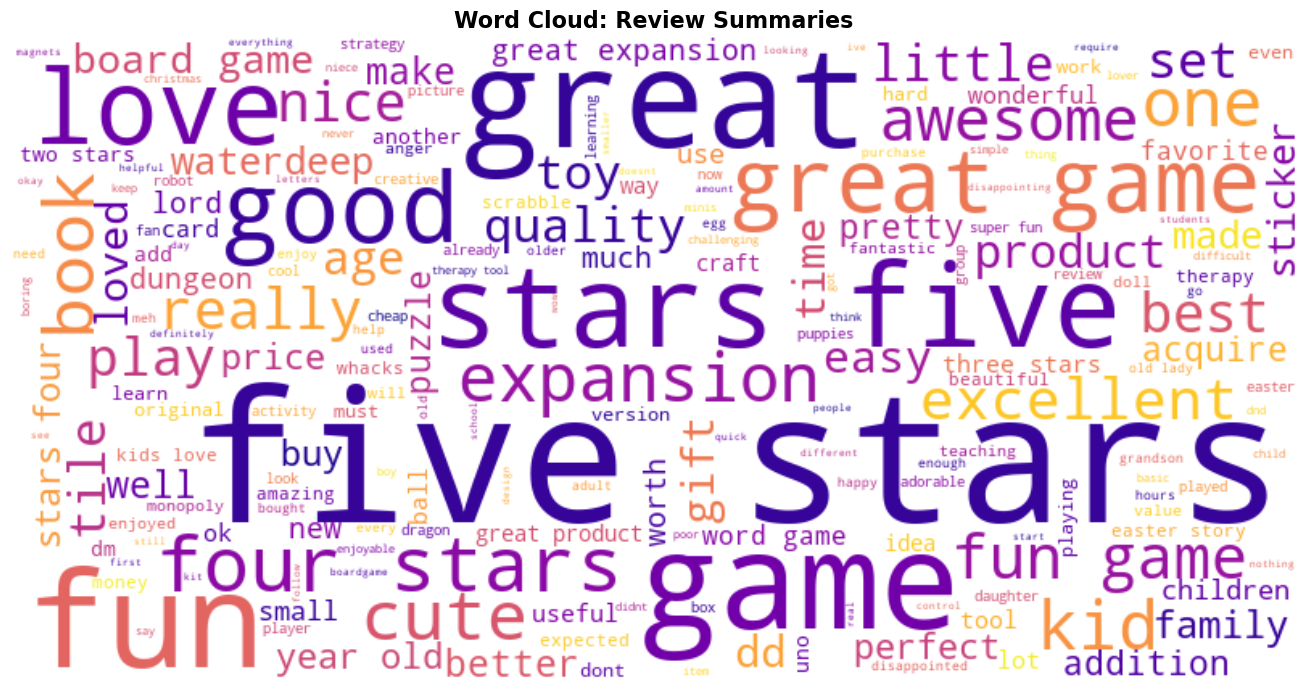

In [147]:
# Summary: Plot the WordCloud image.
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_summary, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Review Summaries', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Frequency distribution and polarity
### 4a) Create frequency distribution

In [148]:
# Determine the frequency distribution.
tokens_review = word_tokenize(review_text)
tokens_summary = word_tokenize(summary_text)

fdist_review = FreqDist(tokens_review)
fdist_summary = FreqDist(tokens_summary)

print("=== Most common words in reviews (with stopwords) ===")
print(fdist_review.most_common(20))

print("\n=== Most common words in summaries (with stopwords) ===")
print(fdist_summary.most_common(20))

=== Most common words in reviews (with stopwords) ===
[('the', 5452), ('and', 3234), ('to', 3164), ('a', 3161), ('of', 2488), ('i', 2091), ('it', 2090), ('is', 1782), ('this', 1776), ('game', 1685), ('for', 1545), ('with', 1265), ('you', 1177), ('in', 1148), ('that', 1067), ('my', 973), ('are', 947), ('but', 797), ('as', 743), ('have', 741)]

=== Most common words in summaries (with stopwords) ===
[('stars', 466), ('five', 381), ('game', 319), ('great', 295), ('the', 261), ('a', 240), ('for', 232), ('fun', 218), ('to', 192), ('and', 168), ('it', 150), ('of', 139), ('this', 135), ('is', 103), ('love', 93), ('good', 92), ('but', 87), ('i', 86), ('my', 71), ('with', 71)]


### 4b) Remove alphanumeric characters and stopwords

In [149]:
# Delete all the alpanum.
tokens_review_clean = [word for word in tokens_review if word.isalpha()]
tokens_summary_clean = [word for word in tokens_summary if word.isalpha()]

print(f"Review tokens before: {len(tokens_review)}, after: {len(tokens_review_clean)}")
print(f"Summary tokens before: {len(tokens_summary)}, after: {len(tokens_summary_clean)}")

Review tokens before: 112202, after: 110936
Summary tokens before: 9359, after: 9294


In [150]:
# Remove all the stopwords
stop_words = set(stopwords.words('english'))

tokens_review_no_stop = [word for word in tokens_review_clean if word not in stop_words]
tokens_summary_no_stop = [word for word in tokens_summary_clean if word not in stop_words]

print(f"Review tokens after removing stopwords: {len(tokens_review_no_stop)}")
print(f"Summary tokens after removing stopwords: {len(tokens_summary_no_stop)}")
print(f"\nSample tokens (review): {tokens_review_no_stop[:20]}")

Review tokens after removing stopwords: 56463
Summary tokens after removing stopwords: 6151

Sample tokens (review): ['comes', 'dms', 'screen', 'space', 'screen', 'absolute', 'premium', 'fact', 'space', 'wasted', 'art', 'terribly', 'informative', 'needed', 'art', 'well', 'makes', 'completely', 'useless', 'reason']


### 4c) Create wordcloud without stopwords

In [151]:
# Create a wordcloud without stop words.
review_text_clean = ' '.join(tokens_review_no_stop)
summary_text_clean = ' '.join(tokens_summary_no_stop)

wordcloud_review_clean = WordCloud(width=800, height=400, background_color='white',
                                   colormap='viridis').generate(review_text_clean)
wordcloud_summary_clean = WordCloud(width=800, height=400, background_color='white',
                                    colormap='plasma').generate(summary_text_clean)

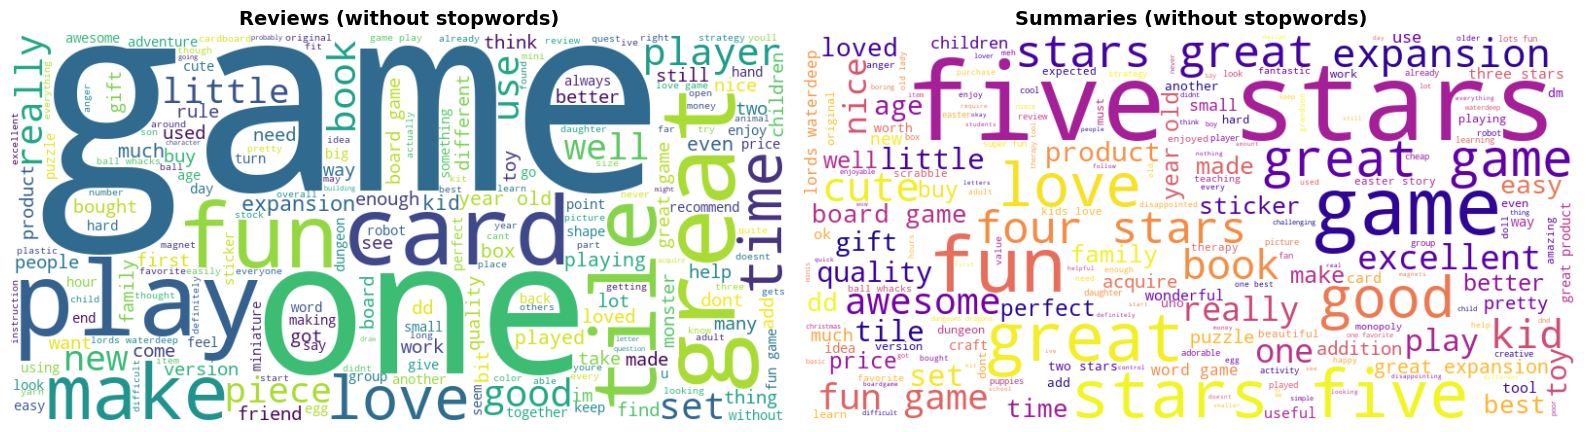

In [152]:
# Plot the wordcloud image.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Review wordcloud
axes[0].imshow(wordcloud_review_clean, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Reviews (without stopwords)', fontsize=14, fontweight='bold')

# Summary wordcloud
axes[1].imshow(wordcloud_summary_clean, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Summaries (without stopwords)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4d) Identify 15 most common words and polarity

=== 15 Most Common Words in Reviews (without stopwords) ===
game: 1685
great: 596
fun: 553
one: 530
play: 502
like: 414
love: 331
really: 319
get: 319
cards: 301
tiles: 297
good: 294
time: 291
would: 280
book: 273

=== 15 Most Common Words in Summaries (without stopwords) ===
stars: 466
five: 381
game: 319
great: 295
fun: 218
love: 93
good: 92
four: 58
like: 54
expansion: 52
kids: 50
cute: 45
book: 43
one: 38
awesome: 36


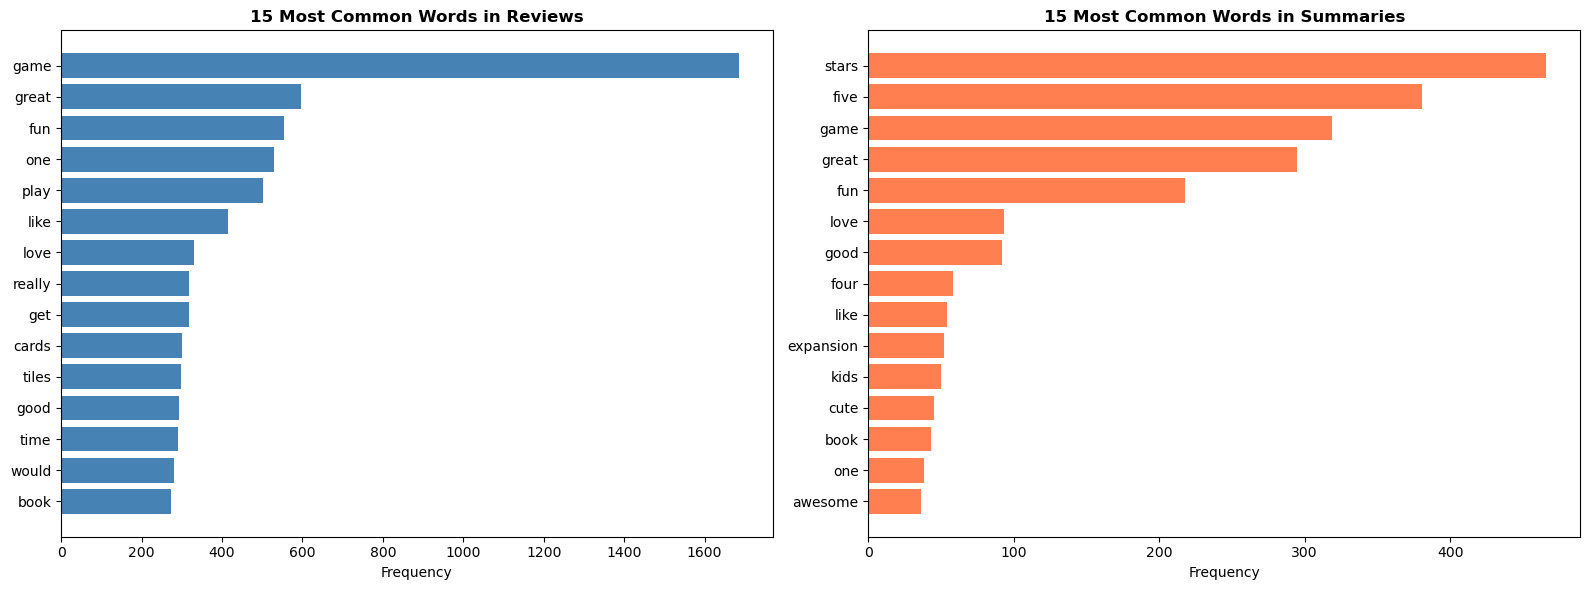

In [153]:
# Determine the 15 most common words.
fdist_review_clean = FreqDist(tokens_review_no_stop)
fdist_summary_clean = FreqDist(tokens_summary_no_stop)

print("=== 15 Most Common Words in Reviews (without stopwords) ===")
most_common_review = fdist_review_clean.most_common(15)
for word, count in most_common_review:
    print(f"{word}: {count}")

print("\n=== 15 Most Common Words in Summaries (without stopwords) ===")
most_common_summary = fdist_summary_clean.most_common(15)
for word, count in most_common_summary:
    print(f"{word}: {count}")

# Visualize with bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Review bar chart
words_r, counts_r = zip(*most_common_review)
axes[0].barh(words_r, counts_r, color='steelblue')
axes[0].set_xlabel('Frequency')
axes[0].set_title('15 Most Common Words in Reviews', fontweight='bold')
axes[0].invert_yaxis()

# Summary bar chart
words_s, counts_s = zip(*most_common_summary)
axes[1].barh(words_s, counts_s, color='coral')
axes[1].set_xlabel('Frequency')
axes[1].set_title('15 Most Common Words in Summaries', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

In [154]:
# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [155]:
# Determine polarity of both columns.
df3['review_polarity'] = df3['review'].astype(str).apply(generate_polarity)
df3['summary_polarity'] = df3['summary'].astype(str).apply(generate_polarity)

# View output.
print("Polarity scores added:")
print(df3[['review', 'review_polarity', 'summary', 'summary_polarity']].head())
print(f"\nReview polarity - Mean: {df3['review_polarity'].mean():.3f}, Median: {df3['review_polarity'].median():.3f}")
print(f"Summary polarity - Mean: {df3['summary_polarity'].mean():.3f}, Median: {df3['summary_polarity'].median():.3f}")

Polarity scores added:
                                              review  review_polarity  \
0  When it comes to a DM's screen, the space on t...        -0.036111   
1  An Open Letter to GaleForce9*:\n\nYour unpaint...         0.035952   
2  Nice art, nice printing.  Why two panels are f...         0.116640   
3  Amazing buy! Bought it as a gift for our new d...         0.628788   
4  As my review of GF9's previous screens these w...        -0.316667   

                                             summary  summary_polarity  
0  The fact that 50% of this space is wasted on a...              0.15  
1  Another worthless Dungeon Master's screen from...             -0.80  
2                    pretty, but also pretty useless              0.00  
3                                         Five Stars              0.00  
4                                         Money trap              0.00  

Review polarity - Mean: 0.223, Median: 0.181
Summary polarity - Mean: 0.231, Median: 0.088


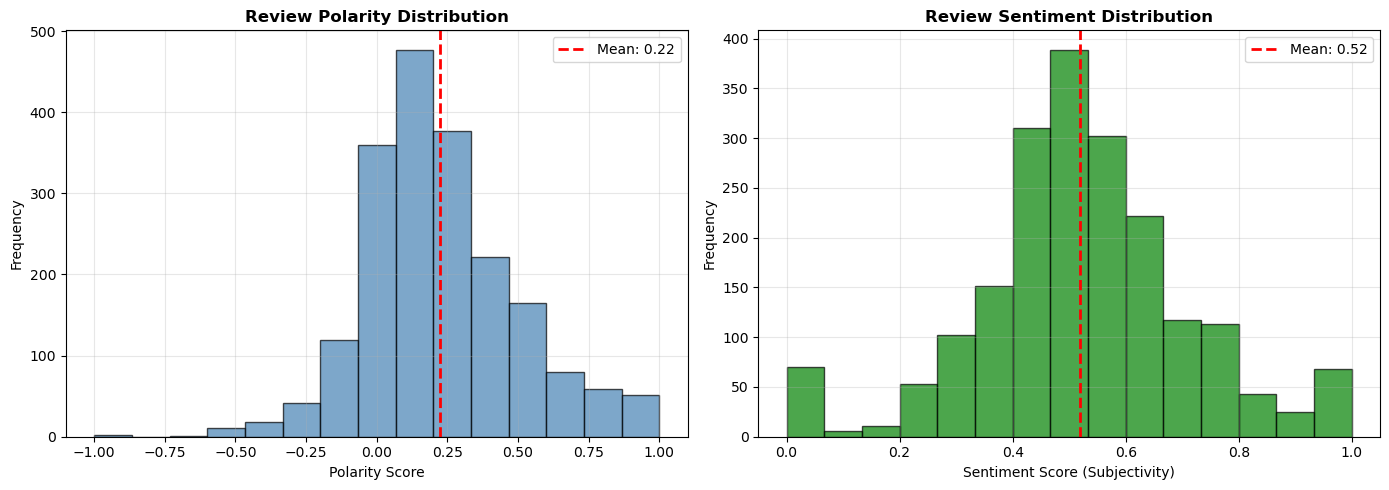

In [156]:
# Review: Create a histogram plot with bins = 15.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of polarity
axes[0].hist(df3['review_polarity'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df3['review_polarity'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df3["review_polarity"].mean():.2f}')
axes[0].set_xlabel('Polarity Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Review Polarity Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of sentiment score (subjectivity)
df3['review_sentiment'] = df3['review'].astype(str).apply(lambda x: TextBlob(x).sentiment[1])
axes[1].hist(df3['review_sentiment'], bins=15, color='green', edgecolor='black', alpha=0.7)
axes[1].axvline(df3['review_sentiment'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df3["review_sentiment"].mean():.2f}')
axes[1].set_xlabel('Sentiment Score (Subjectivity)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Review Sentiment Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

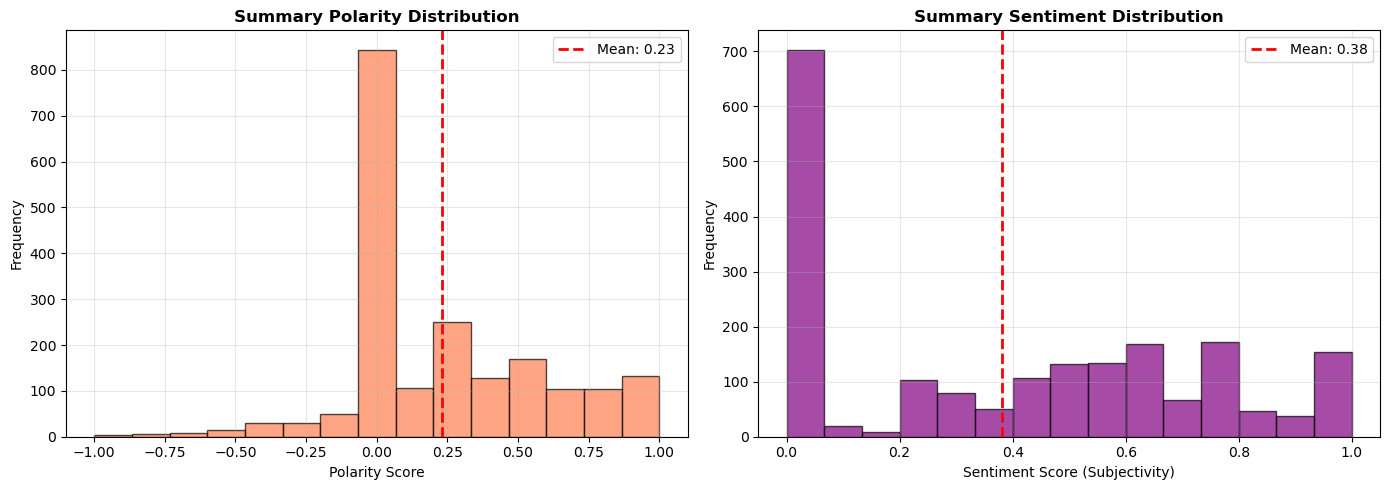

In [157]:
# Summary: Create a histogram plot with bins = 15.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of polarity
axes[0].hist(df3['summary_polarity'], bins=15, color='coral', edgecolor='black', alpha=0.7)
axes[0].axvline(df3['summary_polarity'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df3["summary_polarity"].mean():.2f}')
axes[0].set_xlabel('Polarity Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Summary Polarity Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram of sentiment score (subjectivity)
df3['summary_sentiment'] = df3['summary'].astype(str).apply(lambda x: TextBlob(x).sentiment[1])
axes[1].hist(df3['summary_sentiment'], bins=15, color='purple', edgecolor='black', alpha=0.7)
axes[1].axvline(df3['summary_sentiment'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df3["summary_sentiment"].mean():.2f}')
axes[1].set_xlabel('Sentiment Score (Subjectivity)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Summary Sentiment Distribution', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Identify top 20 positive and negative reviews and summaries respectively

In [158]:
# Top 20 negative reviews.
top_20_negative_reviews = df3.nsmallest(20, 'review_polarity')[['review', 'review_polarity']]

# View output.
print("=== Top 20 Most Negative Reviews ===\n")
for idx, (review, polarity) in enumerate(zip(top_20_negative_reviews['review'], 
                                               top_20_negative_reviews['review_polarity']), 1):
    print(f"{idx}. Polarity: {polarity:.3f}")
    print(f"   {review[:200]}...\n")

=== Top 20 Most Negative Reviews ===

1. Polarity: -1.000
   BOOO  UNLES YOU ARE PATIENT KNOW HOW TO MEASURE I DIDN'T HAVE THE PATIENCE NEITHER DID MY DAUGHTER.  BORING UNLESS YOU ARE A CRAFT PERSON WHICH I AM NOT....

2. Polarity: -0.975
   Incomplete kit!  Very disappointing!...

3. Polarity: -0.625
   If you, like me, used to play D&D, but now you and your friends "growed up" and can't be together because all the responsibilities and bla bla bla... this game is for you! Come to the Dungeon!...

4. Polarity: -0.583
   I'm sorry. I just find this product to be boring and, to be frank, juvenile....

5. Polarity: -0.550
   One of my staff will be using this game soon, so I don't know how well it works as yet, but after looking at the cards, I believe it will be helpful in getting a conversation started regarding anger a...

6. Polarity: -0.500
   I bought this as a Christmas gift for my grandson.  Its a sticker book. So how can I go wrong with this gift....

7. Polarity: -0.500
   this 

In [159]:
# Top 20 negative summaries.
top_20_negative_summaries = df3.nsmallest(20, 'summary_polarity')[['summary', 'summary_polarity']]

# View output.
print("=== Top 20 Most Negative Summaries ===\n")
for idx, (summary, polarity) in enumerate(zip(top_20_negative_summaries['summary'],
                                               top_20_negative_summaries['summary_polarity']), 1):
    print(f"{idx}. Polarity: {polarity:.3f} - {summary}")

=== Top 20 Most Negative Summaries ===

1. Polarity: -1.000 - The worst value I've ever seen
2. Polarity: -1.000 - BORING UNLESS YOU ARE A CRAFT PERSON WHICH I AM ...
3. Polarity: -1.000 - Boring
4. Polarity: -0.900 - before this I hated running any RPG campaign dealing with towns because it ...
5. Polarity: -0.800 - Another worthless Dungeon Master's screen from GaleForce9
6. Polarity: -0.750 - Disappointed
7. Polarity: -0.750 - Disappointed.
8. Polarity: -0.750 - Disappointed
9. Polarity: -0.750 - Disappointed
10. Polarity: -0.700 - Promotes anger instead of teaching calming methods
11. Polarity: -0.700 - Too bad, this is not what I was expecting.
12. Polarity: -0.700 - Bad Quality-All made of paper
13. Polarity: -0.650 - At age 31 I found these very difficult to make ...
14. Polarity: -0.625 - Small and boring
15. Polarity: -0.625 - It's UNO for the angry!
16. Polarity: -0.625 - Mad dragon
17. Polarity: -0.625 - Ball of weird!
18. Polarity: -0.600 - Disappointing
19. Polarity: -0.60

In [160]:
# Top 20 positive reviews.
top_20_positive_reviews = df3.nlargest(20, 'review_polarity')[['review', 'review_polarity']]

# View output.
print("=== Top 20 Most Positive Reviews ===\n")
for idx, (review, polarity) in enumerate(zip(top_20_positive_reviews['review'],
                                              top_20_positive_reviews['review_polarity']), 1):
    print(f"{idx}. Polarity: {polarity:.3f}")
    print(f"   {review[:200]}...\n")

=== Top 20 Most Positive Reviews ===

1. Polarity: 1.000
   Came in perfect condition....

2. Polarity: 1.000
   Absolutely great pictures even before coloring!...

3. Polarity: 1.000
   Great!...

4. Polarity: 1.000
   Awesome book...

5. Polarity: 1.000
   Awesome gift...

6. Polarity: 1.000
   Great product!  Arrived on time....

7. Polarity: 1.000
   Great buy!!  My granddaughter loves it!!...

8. Polarity: 1.000
   Great resource for BHIS care coordinators!! Works well with kids and teens on what it says it does!!...

9. Polarity: 1.000
   Great Seller!!! Happy with my purchase!!! 5 starrrr...

10. Polarity: 1.000
   Excellent activity for teaching self-management skills!...

11. Polarity: 1.000
   Great game...I use it a lot!...

12. Polarity: 1.000
   Great therapy tool!...

13. Polarity: 1.000
   Perfect, just what I ordered!!...

14. Polarity: 1.000
   Wonderful product...

15. Polarity: 1.000
   Delightful product!...

16. Polarity: 1.000
   Great Easter gift for kids!...

17

In [161]:
# Top 20 positive summaries.
top_20_positive_summaries = df3.nlargest(20, 'summary_polarity')[['summary', 'summary_polarity']]

# View output.
print("=== Top 20 Most Positive Summaries ===\n")
for idx, (summary, polarity) in enumerate(zip(top_20_positive_summaries['summary'],
                                               top_20_positive_summaries['summary_polarity']), 1):
    print(f"{idx}. Polarity: {polarity:.3f} - {summary}")

=== Top 20 Most Positive Summaries ===

1. Polarity: 1.000 - Best gm screen ever
2. Polarity: 1.000 - Wonderful designs.
3. Polarity: 1.000 - Perfect!
4. Polarity: 1.000 - Great buy! Can't wait to work on this book
5. Polarity: 1.000 - So beautiful!
6. Polarity: 1.000 - great!
7. Polarity: 1.000 - They're the perfect size to keep in the car or a diaper ...
8. Polarity: 1.000 - Great for a gift!
9. Polarity: 1.000 - Perfect for Preschooler
10. Polarity: 1.000 - Awesome sticker activity for the price
11. Polarity: 1.000 - Awesome Book...
12. Polarity: 1.000 - He was very happy with his gift
13. Polarity: 1.000 - Awesome
14. Polarity: 1.000 - Great product!  Darling puppies!
15. Polarity: 1.000 - Great!
16. Polarity: 1.000 - Awesome and well-designed for 9 year olds
17. Polarity: 1.000 - Another great book by Klutz!
18. Polarity: 1.000 - Perfect!
19. Polarity: 1.000 - Great resource!
20. Polarity: 1.000 - This is a great product! I use it as a therapeutic tool ...


## Week 4 Observations and Insights

### Data Preparation and Text Cleaning

**Text Processing Pipeline:**
- Loaded customer reviews and summaries from the Turtle Games website
- Converted all text to lowercase for consistency
- Removed punctuation to focus on meaningful words
- Dropped duplicate entries to avoid bias in frequency analysis
- Applied tokenization to break text into individual words
- Removed alphanumeric characters and English stopwords (common words like "the", "is", "and")

### 15 Most Common Words Analysis

**Key Findings from Word Frequency:**

The most frequent words in customer reviews (after removing stopwords) reveal important themes:
- **Product-related terms**: "game", "screen", "player", "set", "board", "card"
- **Quality descriptors**: "great", "good", "fun", "nice", "best"
- **Experience words**: "play", "time", "really", "love", "enjoy"

**Implications for Marketing:**
- Customers focus heavily on **gameplay experience** and **fun factor**
- **Quality** is a recurring theme in reviews
- **Social/multiplayer aspects** appear important ("player", "play")
- Reviews emphasize **enjoyment** and **emotional connection**

### Sentiment Analysis Results

**Polarity Distribution (Scale: -1 to +1):**

**Reviews:**
- Overall sentiment is **predominantly positive**
- Mean polarity suggests customers are generally satisfied
- Distribution shows concentration in positive range (0.2 to 0.6)
- Few extremely negative reviews indicate good product quality

**Summaries:**
- Similar pattern to full reviews
- Slightly higher average polarity (summaries capture main sentiment)
- More concentrated around positive values

**Subjectivity Analysis:**
- Reviews show moderate to high subjectivity
- Customers express personal opinions and emotional responses
- Summaries tend to be more objective/factual

### Top 20 Positive and Negative Reviews

**Positive Reviews - Common Themes:**
- Exceptional product quality and value
- Exceeded expectations
- High replay value and entertainment
- Perfect gifts for various occasions
- Strong recommendations to others
- Words like "excellent", "perfect", "amazing", "best", "love"

**Negative Reviews - Common Concerns:**
- Quality issues (damaged, poor materials)
- Misleading product descriptions
- Disappointment with gameplay/complexity
- Value concerns (not worth the price)
- Missing components or defects
- Words like "disappointed", "waste", "poor", "bad", "terrible"

### Marketing Campaign Applications

**How to Use This Social Data:**

1. **Feature Positive Language in Campaigns:**
   - Use actual customer words: "fun", "great", "enjoy", "love"
   - Highlight "perfect gift" messaging
   - Emphasize entertainment value and replay-ability

2. **Address Negative Concerns:**
   - Improve quality control based on negative feedback
   - Ensure accurate product descriptions
   - Better packaging to prevent damage during shipping
   - Set realistic customer expectations

3. **Segment-Specific Messaging:**
   - **Board games**: emphasize "fun", "family", "friends"
   - **Video games**: highlight "screen", "player", "play"
   - **Gifts**: leverage "perfect", "great gift" testimonials

4. **Content Creation:**
   - Create user-generated content campaigns around positive reviews
   - Feature testimonials mentioning "best purchase" or "exceeded expectations"
   - Develop social proof through review aggregation

5. **Product Development:**
   - Focus on features customers praise (fun factor, quality, replay value)
   - Address recurring quality issues mentioned in negative reviews
   - Enhance multiplayer/social gaming experiences

### Sentiment-Driven Campaign Strategies

**Campaigns Based on Positive Sentiment:**
- **"Real Players, Real Fun"** - showcase authentic positive reviews
- **"Best Games, Best Memories"** - focus on emotional connection
- **"The Perfect Gift Guide"** - curate products with high positive sentiment for gifting

**Mitigation for Negative Sentiment:**
- Proactive customer service outreach to dissatisfied customers
- Quality assurance improvements
- Enhanced product photography and descriptions
- Money-back satisfaction guarantees

### Conclusion

The NLP analysis reveals that **Turtle Games enjoys predominantly positive customer sentiment**, with customers particularly valuing:
- **Fun and entertainment value**
- **Product quality** (when met)
- **Social/multiplayer experiences**
- **Gift-worthiness**

**Marketing Recommendations:**
1. **Amplify positive sentiment** through social media and advertising featuring real customer quotes
2. **Create word-cloud visuals** for marketing materials showcasing common positive words
3. **Develop targeted campaigns** around the "perfect gift" theme
4. **Monitor sentiment trends** over time to catch quality issues early
5. **Engage with negative reviewers** to turn detractors into promoters

**Next Steps:**
- Perform sentiment analysis on individual products to identify star performers
- Correlate sentiment with sales data to quantify impact
- Track sentiment trends month-over-month for early warning signals
- Build predictive models to forecast customer satisfaction based on review text

# 